# E83 · Bayesian quantile regression, and when it lies

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: a random sample of 20,000 of the 3.49 million **singleton births in the United States in 2023** from the NCHS natality public-use file (birth certificates; public domain). We model birth weight on the mother's age, smoking, pre-pregnancy BMI and diabetes, weight gain, hypertension and more, and draw **birth-weight-for-gestational-age centile curves**. Plus a simulation with a known truth |
| **You will learn** | The **check (pinball) loss** and why its minimiser is a quantile · quantile regression as a linear programme, solved with a 50-line **Frisch-Newton interior-point** method · effects that differ across the distribution: the **quantile process** (coefficient against $\tau$) · the **asymmetric Laplace** as a *working* likelihood (`pm.AsymmetricLaplace(q=...)`): its posterior mode is the classical estimate, its posterior spread is **wrong** - and changes if you measure in grams instead of kilograms · a **coverage simulation** with known truth: 90% credible intervals that cover 65% · fixes: the **sandwich adjustment** of Yang, Wang & He, and a **generalised (Gibbs) posterior** whose learning rate is calibrated by the bootstrap · **quantile crossing** when quantiles are fitted one at a time, **rearrangement**, and a joint model with **monotone increments** across quantile levels · the generative alternative: a **sinh-arcsinh location-scale-shape regression** from which every quantile follows coherently · comparing all of them on held-out births with **pinball loss, interval scores and PIT** |

## The setting

Birth weight is one of the most studied numbers in medicine, and almost nobody cares about its
average. A baby of 3.3 kg and one of 3.5 kg are both fine. What matters are the **tails**: babies under
2,500 g ("low birth weight", about 7% of US births) carry most of the risk of death and disability,
and babies over 4,000 g ("macrosomia") bring their own problems at delivery. A clinician's questions are
about quantiles: *does smoking shift the whole distribution down, or mainly the lower tail? Does
diabetes before pregnancy make babies bigger, or just more variable?*

Ordinary regression answers a different question - how the **mean** moves - and assumes every
quantile moves by the same amount. **Quantile regression** (Koenker & Bassett 1978) fits each quantile
directly. Koenker & Hallock (2001, *Journal of Economic Perspectives*) made US birth weights the
textbook example; we redo it on 2023 births.

Doing it the Bayesian way looks easy: there is a distribution, the **asymmetric Laplace**, whose
likelihood is maximised exactly at the quantile-regression estimate, and PyMC has it. It is used in
many papers and packages (`bayesQR`, `brms`'s `asym_laplace`). But nobody believes birth weights *are*
asymmetric-Laplace distributed - it is a **working likelihood** - and a posterior built on a wrong
likelihood can put its centre in the right place and its width in the wrong one. This notebook measures
how wrong, fixes it two ways, and then asks whether we should model the whole distribution instead.

| part | question | tool |
|---|---|---|
| A | What does a quantile minimise? | the check loss, linear programming, a Frisch-Newton solver |
| B | Do the effects differ across the distribution? | classical quantile regression on 2023 births, bootstrap, the quantile process |
| C | Can a likelihood give us quantile regression? | the asymmetric Laplace in PyMC; mode vs spread; the units trap |
| D | How wrong are its credible intervals? | a simulation with known truth, coverage, theory |
| E | How do we fix them? | sandwich (Yang-Wang-He) adjustment; a Gibbs posterior with a bootstrap-calibrated learning rate |
| F | What if the fitted quantiles cross? | birth-weight-for-gestational-age centiles; rearrangement; monotone increments |
| G | Or model the whole distribution? | sinh-arcsinh regression; derived quantile effects; held-out pinball loss, interval score, PIT |

E41 built growth charts from a *distributional* model (LMS / Box-Cox t); here we start from the
*quantiles* and see what that approach can and cannot give.

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import scipy.sparse as sparse
from scipy import integrate, special, stats
from scipy.interpolate import BSpline
from scipy.optimize import linprog

from pymc_challenges import data

RANDOM_SEED = 83
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*sample_stats.*")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
T_START = time.time()

BLUE, ORANGE, AQUA, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0"
INK, MUTED, LIGHT = "#0b0b0b", "#8a8984", "#d9d8d3"


def check_loss(r, tau):
    """The check (pinball) loss rho_tau(r) = r (tau - 1{r < 0}), elementwise."""
    return r * (tau - (r < 0))


def _step_bound(x, dx):
    out = np.full_like(x, 1e20)
    neg = dx < 0
    out[neg] = -x[neg] / dx[neg]
    return out


def rq_fn(X, y, tau, tol=1e-10, max_it=60):
    """Quantile regression by the Frisch-Newton interior-point method (Portnoy & Koenker 1997).

    A NumPy port of Morillo & Koenker's `lp_fnm`: it solves the DUAL linear programme
    max y'a  s.t.  X'a = (1 - tau) X'1,  0 <= a <= 1   and returns the primal coefficients."""
    n, p = X.shape
    A, c, u = X.T, -y, np.ones(n)
    x = (1 - tau) * u
    b = A @ x
    s = u - x
    yy = np.linalg.lstsq(A.T, c, rcond=None)[0]
    r = c - A.T @ yy
    r = r + 0.001 * (r == 0)
    z = np.where(r > 0, r, 0.0)
    w = z - r
    gap, scale = c @ x - yy @ b + w @ u, np.abs(c).sum() + 1.0
    for _ in range(max_it):
        if gap <= tol * scale:
            break
        q = 1 / (z / x + w / s)
        r = z - w
        AQ = A * np.sqrt(q)
        M = AQ @ AQ.T                                   # p x p normal equations
        rhs = np.sqrt(q) * r
        dy = np.linalg.solve(M, AQ @ rhs)
        dx = q * (A.T @ dy - r)
        ds, dz, dw = -dx, -z * (dx / x + 1), -w * (-dx / s + 1)
        fp = min(0.9995 * min(_step_bound(x, dx).min(), _step_bound(s, ds).min()), 1)
        fd = min(0.9995 * min(_step_bound(w, dw).min(), _step_bound(z, dz).min()), 1)
        if min(fp, fd) < 1:                             # Mehrotra-type corrector step
            mu = z @ x + w @ s
            g = (z + fd * dz) @ (x + fp * dx) + (w + fd * dw) @ (s + fp * ds)
            mu = mu * (g / mu) ** 3 / (2 * n)
            dxdz, dsdw = dx * dz, ds * dw
            xi = mu * (1 / x - 1 / s)
            rhs = rhs + np.sqrt(q) * (dxdz - dsdw - xi)
            dy = np.linalg.solve(M, AQ @ rhs)
            dx = q * (A.T @ dy + xi - r - dxdz + dsdw)
            ds = -dx
            dz = mu / x - z - z * dx / x - dxdz
            dw = mu / s - w - w * ds / s - dsdw
            fp = min(0.9995 * min(_step_bound(x, dx).min(), _step_bound(s, ds).min()), 1)
            fd = min(0.9995 * min(_step_bound(w, dw).min(), _step_bound(z, dz).min()), 1)
        x, s = x + fp * dx, s + fp * ds
        yy, w, z = yy + fd * dy, w + fd * dw, z + fd * dz
        gap = c @ x - yy @ b + w @ u
    return -yy


def rq_linprog(X, y, tau):
    """The same problem as a primal LP for scipy's HiGHS: min tau 1'u + (1 - tau) 1'v, X b + u - v = y."""
    n, p = X.shape
    A = sparse.hstack([sparse.csr_matrix(X), sparse.eye(n), -sparse.eye(n)]).tocsc()
    cost = np.r_[np.zeros(p), np.full(n, tau), np.full(n, 1 - tau)]
    res = linprog(cost, A_eq=A, b_eq=y, bounds=[(None, None)] * p + [(0, None)] * (2 * n), method="highs")
    return res.x[:p]


def pinball(y, q, tau):
    return np.mean(check_loss(y - q, tau))

## A. What does a quantile minimise?

The mean is the number $m$ that minimises the average **squared** distance $\frac1n\sum_i (y_i - m)^2$;
the median minimises the average **absolute** distance. The $\tau$-quantile minimises an
*asymmetric* absolute distance, the **check** or **pinball loss**

$$\rho_\tau(r) = r\,\bigl(\tau - \mathbb 1\{r < 0\}\bigr) = \begin{cases} \tau\, r & r \ge 0 \\ (\tau - 1)\, r & r < 0.\end{cases}$$

For $\tau = 0.1$ an observation *below* the candidate costs 0.9 per gram and one *above* costs 0.1, so
the best candidate sits where 10% of the data are below it: moving it up by a small step gains
$0.9 \times$ (share below) and loses $0.1 \times$ (share above), which balance exactly at share below
$= 0.1$. **Quantile regression** replaces the constant by a linear predictor:

$$\hat\beta(\tau) = \arg\min_\beta \sum_i \rho_\tau(y_i - x_i^\top\beta).$$

The objective is piecewise linear, so this is a **linear programme** (write each residual as $u_i - v_i$
with $u_i, v_i \ge 0$). The solution passes exactly through $p$ of the data points, and no derivative of
the loss exists there - a first hint that likelihood-style curvature arguments will need care.

The data first. `load` only parses the raw codes; unknown values are coded 9, 99, 99.9 or 9999.

In [2]:
data.describe("natality_births")
raw = data.load("natality_births")
print(f"{len(raw):,} singleton births; birth weight unknown for {np.sum(raw.dbwt == 9999)}")
early = raw.oegest_comb < 28
print(f"births before 28 weeks: {early.sum()}; of these, 3rd-trimester cigarettes 'unknown' (99): "
      f"{np.mean(raw.cig_3[early] == 99):.0%}; 1st-trimester cigarettes unknown: {np.mean(raw.cig_1[early] == 99):.0%}")

natality_births: A simple random sample of 20,000 of the 3,491,735 SINGLETON births of 2023 (raw codes; 9 / 99 / 99.9 / 999 / 9999 = unknown, empty = not reported): dob_mm, mager (mother's age), mrace6 (1 White, 2 Black, 3 AIAN, 4 Asian, 5 NHOPI, 6 more than one race), dmar (1 married, 2 unmarried; not reported for California), meduc (1-8 education, 9 unknown), tbo_rec (total birth order), previs (prenatal visits), cig_0..cig_3 (cigarettes per day before pregnancy and in trimesters 1-3), m_ht_in (inches), bmi (pre-pregnancy), pwgt_r (pre-pregnancy weight, lb), wtgain (lb), rf_pdiab / rf_gdiab / rf_ghype (pre-pregnancy diabetes, gestational diabetes, gestational hypertension: Y/N/U), sex (M/F), combgest and oegest_comb (gestation in weeks, combined and obstetric estimate), dbwt (birth weight, grams).
  source: National Center for Health Statistics (NCHS), National Vital Statistics System, Natality public use file 2023 (all 3,605,081 US birth certificates of 2023; codes as in the NCHS 'U

A trap worth a sentence: "cigarettes in the 3rd trimester" is *unknown* for three quarters of the babies
born before 28 weeks - there was no third trimester. Dropping incomplete records on that variable would
silently delete the smallest babies, i.e. the lower tail we care about. We define **smoker** as any
smoking in any trimester (first or second trimester must be known), and drop the few records with other
unknown items.

In [3]:
ok = ((raw.dbwt < 9999) & (raw.cig_1 < 99) & (raw.cig_2 < 99) & (raw.bmi < 99) & (raw.wtgain < 99)
      & (raw.rf_pdiab != "U") & (raw.meduc < 9) & (raw.tbo_rec < 9) & (raw.oegest_comb < 99))
d = raw[ok].reset_index(drop=True).copy()
d["bw"] = d.dbwt / 1000                                     # kilograms
d["boy"] = (d.sex == "M").astype(float)
d["black"] = (d.mrace6 == 2).astype(float)
d["age"] = (d.mager - 30) / 10                              # per decade, 0 = 30 years
d["first"] = (d.tbo_rec == 1).astype(float)
d["college"] = (d.meduc >= 6).astype(float)                 # bachelor's degree or more
d["smoker"] = ((d.cig_1 > 0) | (d.cig_2 > 0) | ((d.cig_3 > 0) & (d.cig_3 < 99))).astype(float)
d["bmi5"] = (d.bmi - 25) / 5                                # per 5 BMI units, 0 = 25
d["gain10"] = (d.wtgain - 30) / 10                          # per 10 lb gained, 0 = 30 lb
d["pre_diab"] = (d.rf_pdiab == "Y").astype(float)
d["gest_hyp"] = (d.rf_ghype == "Y").astype(float)
COVS = ["boy", "black", "age", "first", "college", "smoker", "bmi5", "gain10", "pre_diab", "gest_hyp"]
COEF = ["intercept"] + COVS
N_TRAIN = 6000
perm = rng.permutation(len(d))
tr, te = d.iloc[perm[:N_TRAIN]].reset_index(drop=True), d.iloc[perm[N_TRAIN:]].reset_index(drop=True)
X, y = np.column_stack([np.ones(N_TRAIN)] + [tr[c].to_numpy() for c in COVS]), tr.bw.to_numpy()
Xte, yte = np.column_stack([np.ones(len(te))] + [te[c].to_numpy() for c in COVS]), te.bw.to_numpy()
print(f"{len(d):,} complete records ({ok.mean():.1%}); training {len(tr):,}, held out {len(te):,}")
print(f"low birth weight (< 2.5 kg): {np.mean(d.bw < 2.5):.1%}; macrosomia (> 4 kg): {np.mean(d.bw > 4):.1%}")
print(pd.DataFrame({"share / mean": tr[COVS].mean(), "count (binary)": tr[COVS].sum()}).round(3).T.to_string())

18,936 complete records (94.7%); training 6,000, held out 12,936
low birth weight (< 2.5 kg): 6.9%; macrosomia (> 4 kg): 7.1%
                     boy    black      age     first   college   smoker      bmi5   gain10  pre_diab  gest_hyp
share / mean       0.511    0.153   -0.051     0.328     0.364    0.031     0.542   -0.077     0.013     0.096
count (binary)  3068.000  918.000 -308.200  1971.000  2182.000  186.000  3254.040 -461.400    76.000   576.000


Before any regression: the loss curves for three quantile levels on the 6,000 training weights, and
a check that the minimiser is the sample quantile.

tau = 0.1: argmin of the average check loss 2.640 kg, sample quantile 2.637 kg
tau = 0.5: argmin of the average check loss 3.300 kg, sample quantile 3.300 kg
tau = 0.9: argmin of the average check loss 3.915 kg, sample quantile 3.912 kg


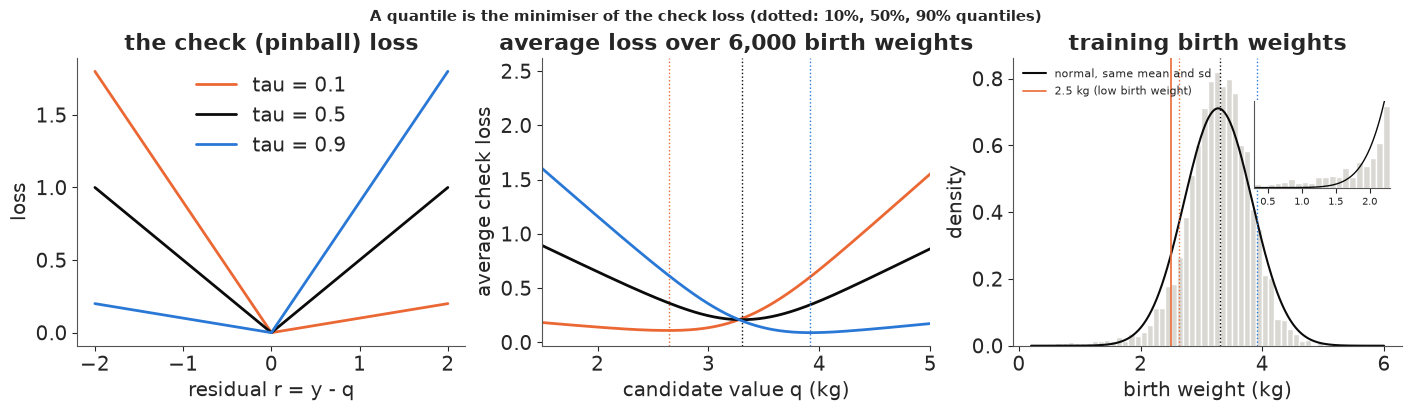

In [4]:
cand = np.linspace(0.5, 5.0, 901)
TAU3 = (0.1, 0.5, 0.9)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ax = axes[0]
r_ = np.linspace(-2, 2, 201)
for tau, c in zip(TAU3, (ORANGE, INK, BLUE)):
    ax.plot(r_, check_loss(r_, tau), color=c, lw=2, label=f"tau = {tau}")
ax.set(xlabel="residual r = y - q", ylabel="loss", title="the check (pinball) loss")
ax.legend()
ax = axes[1]
for tau, c in zip(TAU3, (ORANGE, INK, BLUE)):
    loss = np.array([pinball(y, q, tau) for q in cand])
    ax.plot(cand, loss, color=c, lw=2)
    ax.axvline(cand[np.argmin(loss)], color=c, ls=":", lw=1)
    print(f"tau = {tau}: argmin of the average check loss {cand[np.argmin(loss)]:.3f} kg, "
          f"sample quantile {np.quantile(y, tau):.3f} kg")
ax.set(xlabel="candidate value q (kg)", ylabel="average check loss", xlim=(1.5, 5),
       title="average loss over 6,000 birth weights")
ax = axes[2]
ax.hist(y, bins=np.arange(0.2, 6.0, 0.1), density=True, color=LIGHT, edgecolor="white")
xx = np.linspace(0.2, 6, 400)
ax.plot(xx, stats.norm.pdf(xx, y.mean(), y.std()), color=INK, lw=1.5, label="normal, same mean and sd")
for tau, c in zip(TAU3, (ORANGE, INK, BLUE)):
    ax.axvline(np.quantile(y, tau), color=c, ls=":", lw=1)
ax.axvline(2.5, color=ORANGE, lw=1.2, label="2.5 kg (low birth weight)")
ax.set(xlabel="birth weight (kg)", ylabel="density", title="training birth weights")
ax.legend(fontsize=8)
ax_in = ax.inset_axes([0.62, 0.55, 0.35, 0.3])
ax_in.hist(y, bins=np.arange(0.2, 6.0, 0.1), density=True, color=LIGHT, edgecolor="white")
ax_in.plot(xx, stats.norm.pdf(xx, y.mean(), y.std()), color=INK, lw=1)
ax_in.set(xlim=(0.3, 2.3), ylim=(0, 0.12), yticks=[])
ax_in.tick_params(labelsize=7)
fig.suptitle("A quantile is the minimiser of the check loss (dotted: 10%, 50%, 90% quantiles)", fontsize=11);

The minimisers agree with the sample quantiles to the grid spacing (5 g). The histogram shows why tails
need their own model: birth weight has a long **left** tail (the inset: babies born early), far heavier
than a normal distribution with the same mean and sd, and a shorter right tail.

Now the regression. We solve the linear programme two ways: with scipy's general LP solver (HiGHS) and
with a short **Frisch-Newton interior-point** method written above (Portnoy & Koenker 1997; the `"fn"`
method of R's `quantreg`, recommended there for large problems). Interior-point methods walk through the
inside of the feasible set; each step is one weighted least-squares solve with a $p \times p$ system, and a
few dozen steps suffice whatever the sample size. We will need thousands of fits for bootstraps, so speed matters.

In [5]:
for tau in (0.1, 0.9):
    t0 = time.time()
    b_lp = rq_linprog(X, y, tau)
    t_lp = time.time() - t0
    t0 = time.time()
    b_fn = rq_fn(X, y, tau)
    t_fn = time.time() - t0
    print(f"tau = {tau}: HiGHS {t_lp * 1000:.0f} ms, Frisch-Newton {t_fn * 1000:.0f} ms; largest coefficient "
          f"difference {np.abs(b_lp - b_fn).max() * 1000:.4f} g; check loss difference "
          f"{(check_loss(y - X @ b_fn, tau).sum() - check_loss(y - X @ b_lp, tau).sum()) * 1000:.2g} g")

tau = 0.1: HiGHS 678 ms, Frisch-Newton 13 ms; largest coefficient difference 0.0000 g; check loss difference 2.3e-07 g


tau = 0.9: HiGHS 673 ms, Frisch-Newton 13 ms; largest coefficient difference 0.0000 g; check loss difference 1.3e-07 g


Same answer (coefficients agree to better than 0.0001 g), roughly 50 times faster.

## B. Effects that differ across the distribution

We fit seven quantile levels, $\tau \in \{0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95\}$, with the ten
covariates above, plus ordinary least squares (OLS) for the mean. For uncertainty we use the classical
tool, the **pairs bootstrap**: resample births with replacement, refit, repeat 200 times. Plotting each
coefficient against $\tau$ gives the **quantile process**: a flat line means the covariate shifts the
whole distribution; a slope means it stretches or skews it.

In [6]:
TAUS = np.array([0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
K = len(TAUS)
beta_hat = np.array([rq_fn(X, y, t) for t in TAUS])               # K x p
ols = np.linalg.lstsq(X, y, rcond=None)[0]
ols_se = np.sqrt(np.diag(np.linalg.inv(X.T @ X)) * np.sum((y - X @ ols) ** 2) / (N_TRAIN - X.shape[1]))
N_BOOT = 200
rng_b = np.random.default_rng(RANDOM_SEED + 1)
t0 = time.time()
boot = np.empty((N_BOOT, K, X.shape[1]))
for bb in range(N_BOOT):
    i = rng_b.integers(0, N_TRAIN, N_TRAIN)
    boot[bb] = [rq_fn(X[i], y[i], t) for t in TAUS]
print(f"{N_BOOT * K:,} bootstrap fits in {time.time() - t0:.0f} s")
tab = pd.DataFrame(beta_hat.T * 1000, index=COEF, columns=[f"q{t:g}" for t in TAUS]).round(0)
tab["OLS"] = (ols * 1000).round(0)
print("coefficients in grams (intercept: a 30-year-old, BMI 25, 30 lb gain, girl, all other 0)")
print(tab.to_string())
print("bootstrap standard errors (g)")
print(pd.DataFrame(boot.std(0).T * 1000, index=COEF, columns=[f"q{t:g}" for t in TAUS]).round(0).to_string())

1,400 bootstrap fits in 19 s
coefficients in grams (intercept: a 30-year-old, BMI 25, 30 lb gain, girl, all other 0)
            q0.05    q0.1   q0.25    q0.5   q0.75    q0.9   q0.95     OLS
intercept  2390.0  2670.0  2994.0  3297.0  3583.0  3837.0  4010.0  3267.0
boy         101.0    73.0    68.0    94.0   114.0   127.0   119.0    93.0
black      -267.0  -236.0  -175.0  -170.0  -170.0  -147.0  -155.0  -188.0
age        -143.0  -102.0   -53.0   -13.0    29.0    34.0    28.0   -27.0
first      -120.0  -147.0  -111.0  -108.0   -90.0   -70.0   -93.0  -110.0
college     157.0   164.0   108.0    79.0    59.0    28.0    35.0    84.0
smoker     -110.0  -200.0  -157.0  -232.0  -298.0  -237.0  -212.0  -214.0
bmi5         17.0    25.0    43.0    55.0    73.0    82.0   106.0    54.0
gain10      107.0    95.0    78.0    81.0    84.0    81.0    96.0    89.0
pre_diab     15.0  -155.0    -6.0   -31.0    29.0   114.0    75.0    10.0
gest_hyp   -420.0  -291.0  -235.0  -224.0  -230.0  -203.0  -212.0  -2

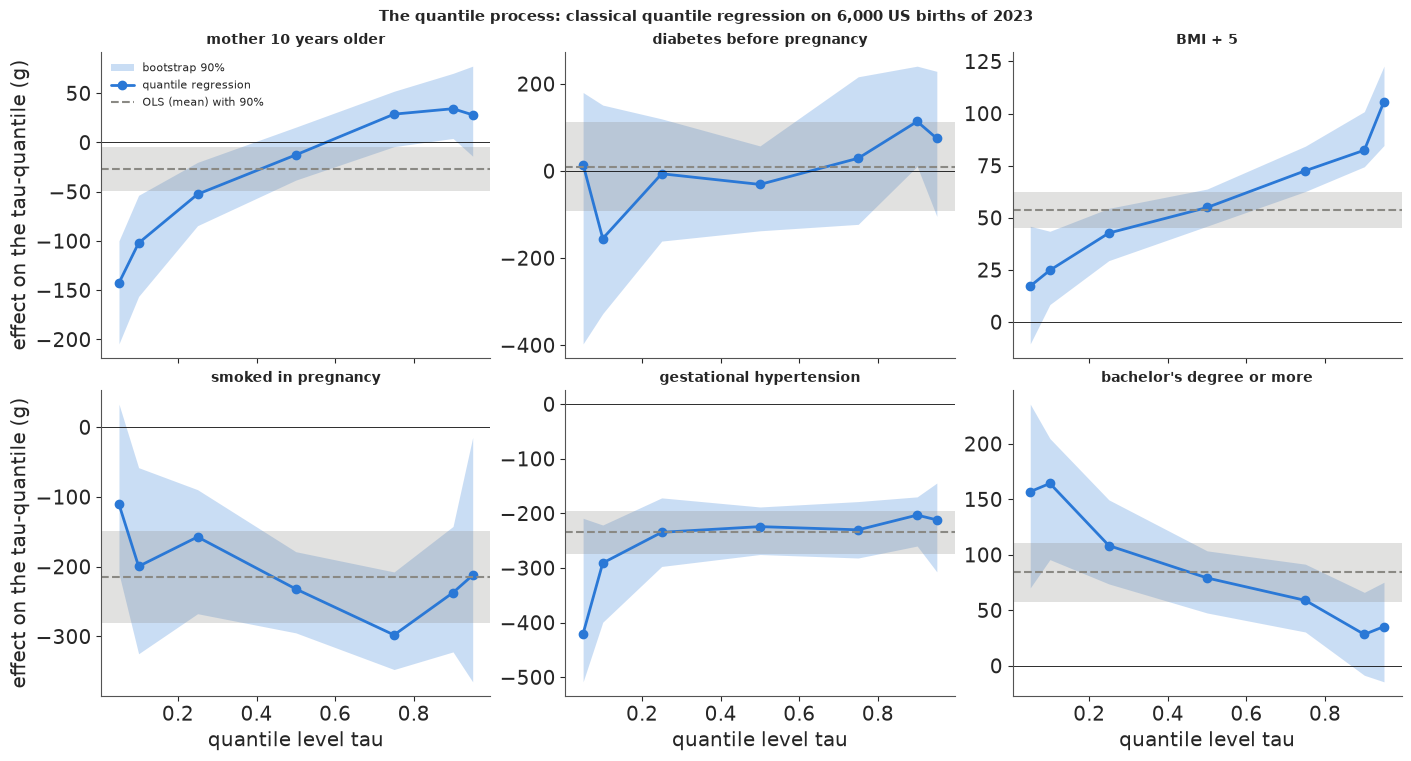

In [7]:
SHOW = ["age", "pre_diab", "bmi5", "smoker", "gest_hyp", "college"]
LABEL = {"age": "mother 10 years older", "pre_diab": "diabetes before pregnancy", "bmi5": "BMI + 5",
         "smoker": "smoked in pregnancy", "gest_hyp": "gestational hypertension",
         "college": "bachelor's degree or more", "boy": "boy", "black": "Black mother",
         "first": "first birth", "gain10": "10 lb more weight gain", "intercept": "intercept"}
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), sharex=True)
for ax, cv in zip(axes.ravel(), SHOW):
    j = COEF.index(cv)
    lo, hi = np.quantile(boot[:, :, j], [0.05, 0.95], axis=0) * 1000
    ax.fill_between(TAUS, lo, hi, color=BLUE, alpha=0.25, lw=0, label="bootstrap 90%")
    ax.plot(TAUS, beta_hat[:, j] * 1000, "o-", color=BLUE, lw=2, label="quantile regression")
    ax.axhspan((ols[j] - 1.645 * ols_se[j]) * 1000, (ols[j] + 1.645 * ols_se[j]) * 1000, color=MUTED, alpha=0.25, lw=0)
    ax.axhline(ols[j] * 1000, color=MUTED, lw=1.5, ls="--", label="OLS (mean) with 90%")
    ax.axhline(0, color=INK, lw=0.6)
    ax.set_title(LABEL[cv], fontsize=10)
axes[0, 0].legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel("quantile level tau")
for ax in axes[:, 0]:
    ax.set_ylabel("effect on the tau-quantile (g)")
fig.suptitle("The quantile process: classical quantile regression on 6,000 US births of 2023", fontsize=11);

Reading the panels (blue bands: bootstrap 90% intervals; grey: the OLS estimate with its 90% interval):

* **Mother's age** is the textbook case of an effect that a mean regression hides. At the median ten
  more years change almost nothing (-13 g, interval includes zero). In the lower tail they cost 100-140 g
  (5% and 10% quantiles); in the upper tail they add about 30 g. OLS reports a single -27 g, an average
  of opposite movements: babies of older mothers are more *spread out* - more small ones, a few more
  large ones - not uniformly lighter.
* **BMI** stretches the distribution upwards: +17 g per 5 BMI units at the 5% quantile, +55 g at the
  median and about +105 g at the 95% quantile. This is the "shifts the upper tail more than the median"
  pattern; the mean (+54 g) misses it completely.
* A **degree** matters most at the bottom (+160 g at the 5-10% quantiles, about +30 g at 90-95%), and
  **gestational hypertension** is a nearly constant -200 to -235 g except in the lower tail (-290 g at 10%,
  -420 g at 5%).
* **Smoking** lowers every quantile, by roughly 100-300 g; with 186 smokers in the training data the bands
  are too wide to say whether the effect varies with $\tau$.
* **Diabetes before pregnancy** is where one might expect a widening (larger babies, but also more
  complications): the estimates swing from -155 g at the 10% quantile to +114 g at the 90% - but with 76
  diabetic mothers the bands are 200-500 g wide, and only the one at 90% excludes zero (just: it starts at
  about +10 g). Rare binary covariates in extreme quantiles are data-hungry.

## C. The asymmetric Laplace as a working likelihood

To make quantile regression Bayesian we need a likelihood. The **asymmetric Laplace distribution** (ALD)
with quantile level $\tau$, location $\mu$ and scale $\sigma$ has density

$$p(y \mid \mu, \sigma, \tau) = \frac{\tau(1-\tau)}{\sigma} \exp\Bigl\{-\frac{\rho_\tau(y - \mu)}{\sigma}\Bigr\},$$

so with $\mu_i = x_i^\top\beta$ the log-likelihood is $-\frac1\sigma\sum_i\rho_\tau(y_i - x_i^\top\beta)$
plus terms without $\beta$: maximising it over $\beta$ **is** quantile regression, and $\mu$ is the
$\tau$-quantile of the ALD (Yu & Moyeed 2001). PyMC has it as `pm.AsymmetricLaplace(mu, b, q=tau)`;
careful, its `b` is a *rate* in a symmetric parameterisation: the check-loss form above corresponds to
$b = \sqrt{\tau(1-\tau)}/\sigma$. We verify that, and that $P(y < \mu) = \tau$, before using it.

In [8]:
q_, sig_, mu_ = 0.9, 0.3, 0.1
yv = np.array([-1.0, 0.0, 0.5, 2.0])
lp_pymc = pm.logp(pm.AsymmetricLaplace.dist(mu=mu_, b=np.sqrt(q_ * (1 - q_)) / sig_, q=q_), yv).eval()
lp_hand = np.log(q_ * (1 - q_) / sig_) - check_loss(yv - mu_, q_) / sig_
draws_ = pm.draw(pm.AsymmetricLaplace.dist(mu=mu_, b=np.sqrt(q_ * (1 - q_)) / sig_, q=q_), 200_000,
                 random_seed=RANDOM_SEED)
print("PyMC logp:", lp_pymc.round(6), "\ncheck loss:", lp_hand.round(6), f"\nP(y < mu) by simulation: {np.mean(draws_ < mu_):.4f}")

PyMC logp: [-1.570639 -1.237306 -2.403973 -6.903973] 
check loss: [-1.570639 -1.237306 -2.403973 -6.903973] 
P(y < mu) by simulation: 0.9000


One model holds all seven quantile levels side by side (they share nothing, so this is seven separate
fits run together). Priors: $\beta \sim N(0, 5)$ in kilograms - effectively flat - and a half-normal
on each $\sigma_\tau$.

In [9]:
Y_rep = np.repeat(y[:, None], K, axis=1)
t0 = time.time()
with pm.Model(coords={"coef": COEF, "tau": TAUS}) as m_ald:
    beta = pm.Normal("beta", 0.0, 5.0, dims=("coef", "tau"))
    sigma = pm.HalfNormal("sigma", 1.0, dims="tau")
    pm.AsymmetricLaplace("y", mu=pt.as_tensor(X) @ beta, b=np.sqrt(TAUS * (1 - TAUS)) / sigma, q=TAUS,
                         observed=Y_rep)
    idata_ald = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
t_ald = time.time() - t0
s_ald = az.summary(idata_ald, var_names=["beta"], round_to=4)
print(f"ALD, 7 quantile levels: {t_ald:.0f} s; divergences {int(idata_ald.sample_stats['diverging'].sum())}; "
      f"max r_hat {s_ald['r_hat'].max():.3f}; min bulk ESS {s_ald['ess_bulk'].min():.0f}; "
      f"tuning steps {idata_ald.posterior.attrs['tuning_steps']}")
post_ald = idata_ald.posterior["beta"].to_numpy().reshape(-1, len(COEF), K)        # S x p x K
sig_ald = idata_ald.posterior["sigma"].to_numpy().reshape(-1, K)

ALD, 7 quantile levels: 23 s; divergences 0; max r_hat 1.005; min bulk ESS 2205; tuning steps 400


**The posterior mode is the classical estimate.** With a flat prior and $\sigma$ profiled out, the log
posterior of $\beta$ is $-n\log\sum_i\rho_\tau(y_i - x_i^\top\beta)$, a decreasing function of the
check loss, so the linear-programming solution must beat every posterior draw:

In [10]:
rows = []
for k, tau in enumerate(TAUS):
    L_draws = check_loss(y[:, None] - X @ post_ald[:, :, k].T, tau).sum(0)
    L_hat = check_loss(y - X @ beta_hat[k], tau).sum()
    sd = post_ald[:, :, k].std(0)
    rows.append({"tau": tau, "check loss at LP (kg)": L_hat, "smallest over 4000 draws": L_draws.min(),
                 "draws beating LP": int(np.sum(L_draws < L_hat - 1e-9)),
                 "max |post. mean - LP| / post. sd": np.max(np.abs(post_ald[:, :, k].mean(0) - beta_hat[k]) / sd),
                 "coef.": COEF[np.argmax(np.abs(post_ald[:, :, k].mean(0) - beta_hat[k]) / sd)]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 tau  check loss at LP (kg)  smallest over 4000 draws  draws beating LP  max |post. mean - LP| / post. sd    coef.
0.05                400.772                   400.841                 0                             0.458    black
0.10                622.485                   622.563                 0                             0.699    first
0.25               1000.613                  1000.766                 0                             0.296   smoker
0.50               1174.427                  1174.518                 0                             0.206  college
0.75                912.136                   912.244                 0                             0.287    first
0.90                500.562                   500.641                 0                             0.516 gest_hyp
0.95                295.952                   295.987                 0                             0.335      age


At every level the linear-programming solution has a smaller check loss than all 4,000 draws: it is
the posterior mode (the $N(0, 5)$ prior is far too weak to move it). The posterior **mean** is a different
point estimate, up to about 0.7 posterior sd away (the "first birth" coefficient at $\tau = 0.1$),
because the posterior of a quantile-regression coefficient is not symmetric when a handful of births near
the fitted line decide it. So far, so good: the working likelihood puts its centre in the right place.

**But the spread is another matter.** Compare the posterior sd of each coefficient with its bootstrap
standard error, which is an honest (if approximate) frequentist measure of how much the estimate
would move in a new sample:

In [11]:
sd_ald = post_ald.std(0).T                                   # K x p
sd_boot = boot.std(0)
ratio_ald = pd.DataFrame(sd_ald / sd_boot, index=[f"tau {t:g}" for t in TAUS], columns=COEF)
print("posterior sd / bootstrap sd, ALD with sigma learned")
print(ratio_ald.round(2).to_string())

posterior sd / bootstrap sd, ALD with sigma learned
          intercept   boy  black   age  first  college  smoker  bmi5  gain10  pre_diab  gest_hyp
tau 0.05       0.46  0.43   0.35  0.45   0.45     0.45    0.42  0.40    0.40      0.37      0.36
tau 0.1        0.52  0.51   0.50  0.52   0.56     0.60    0.56  0.54    0.52      0.49      0.53
tau 0.25       0.66  0.75   0.69  0.67   0.80     0.69    0.71  0.67    0.72      0.70      0.66
tau 0.5        0.87  0.76   0.90  0.77   0.84     0.81    0.92  0.84    0.76      0.79      0.77
tau 0.75       0.75  0.71   0.76  0.72   0.77     0.78    0.73  0.76    0.77      0.63      0.69
tau 0.9        0.54  0.55   0.58  0.59   0.59     0.59    0.59  0.59    0.57      0.54      0.58
tau 0.95       0.50  0.48   0.49  0.44   0.51     0.47    0.35  0.48    0.41      0.50      0.44


Every posterior sd is too small: 0.35-0.46 of the bootstrap sd at $\tau = 0.05$, 0.76-0.92 at the median,
0.35-0.51 at $\tau = 0.95$. A nominal 90% credible interval in the tails is less than half as wide as it
should be. Within one quantile level the ratio is about the same for every coefficient - a hint that it
is a property of the residual distribution at that quantile rather than of the covariate, which Part D
makes precise.

### The units trap

Many implementations fix $\sigma = 1$ ("it cancels in the argmax"). It does cancel in the argmax - and
nowhere else. With $\sigma$ fixed the posterior is $\propto \exp\{-\sum_i\rho_\tau(r_i)\}$, whose
curvature is proportional to the units of $y$. Fit the median regression twice, once in kilograms and
once in grams, both with $\sigma = 1$:

In [12]:
unit_rows = {}
for unit, fac in (("kg", 1.0), ("g", 1000.0)):
    with pm.Model(coords={"coef": COEF}):
        b_ = pm.Normal("beta", 0.0, 5.0 * fac, dims="coef")
        pm.AsymmetricLaplace("y", mu=pt.as_tensor(X) @ b_, b=np.sqrt(0.25) / 1.0, q=0.5, observed=y * fac)
        idu = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    unit_rows[f"sigma = 1 {unit}"] = idu.posterior["beta"].to_numpy().reshape(-1, len(COEF)).std(0) * 1000 / fac
k50 = list(TAUS).index(0.5)
unit_rows["sigma learned"] = sd_ald[k50] * 1000
unit_rows["bootstrap"] = sd_boot[k50] * 1000
print("posterior sd of median-regression coefficients, in grams")
print(pd.DataFrame(unit_rows, index=COEF).loc[["intercept", "age", "smoker", "bmi5", "pre_diab"]].round(2).to_string())

posterior sd of median-regression coefficients, in grams
           sigma = 1 kg  sigma = 1 g  sigma learned  bootstrap
intercept         25.30         0.76          11.34      13.11
age               27.58         1.19          12.91      16.83
smoker            73.03         3.25          33.43      36.39
bmi5              10.59         0.34           4.48       5.32
pre_diab         125.62         4.11          51.21      64.75


Same data, same point estimate, posterior sds that differ by a factor of roughly 20-35 between the two units
(the square-root rule, $\sqrt{1000} \approx 32$, assumes a smooth, near-Gaussian posterior; one about a gram wide
need not be). With $\sigma$ = 1 kg the sds are 1.6-2 times the bootstrap's; with $\sigma$ = 1 g they are 11-17
times too small. Learning $\sigma$ removes the arbitrariness, but, as the previous
table showed, not the error.

## D. How wrong? A simulation with a known truth

On real data we can only compare with the bootstrap, itself an approximation. To measure **coverage**
we need a truth. We simulate 200 datasets of $n = 200$ from a heteroscedastic, skewed model,

$$y = 1 + 2x + (0.5 + 1.5x)\,\varepsilon,\qquad x \sim U(0, 1),\qquad \varepsilon \sim \frac{\text{Gamma}(3) - 3}{\sqrt3},$$

whose $\tau$-quantile is exactly linear: $Q_\tau(y \mid x) = (1 + 0.5\,q_\tau) + (2 + 1.5\,q_\tau)\,x$
with $q_\tau$ the $\tau$-quantile of $\varepsilon$. For each dataset and $\tau \in \{0.5, 0.9\}$ we compute
four intervals for the intercept and slope:

1. **ALD posterior** with $\sigma$ learned (flat prior on $\beta$, Jeffreys prior $1/\sigma$; $\sigma$ then
   integrates out analytically and the posterior of $\beta$ is $\propto L(\beta)^{-n}$, $L$ the total check loss);
2. the same draws **adjusted** by the sandwich formula of Yang, Wang & He (2016, *International Statistical Review*) - below;
3. a **Gibbs posterior** $\propto \exp\{-w\,L(\beta)\}$ with learning rate $w$ calibrated by the bootstrap - below;
4. the **bootstrap percentile** interval (200 resamples) as a frequentist reference.

Posteriors here are sampled with a vectorised random-walk Metropolis sampler (4 chains per dataset,
all 200 datasets at once, with a pilot run to set the proposal) because 1,600 NUTS runs would take too
long; the model has two parameters, so this is safe, and we check it against NUTS on one dataset.

**Why the ALD width is wrong - the sandwich.** For large $n$ the classical estimator is normal with
covariance $\frac{\tau(1-\tau)}{n} D_1^{-1} D_0 D_1^{-1}$, where $D_0 = E[xx^\top]$ and
$D_1 = E[f(Q_\tau \mid x)\,xx^\top]$ involves the conditional density *at the quantile*. The ALD posterior
instead has covariance $\frac{\sigma}{n} D_1^{-1}$: it gets the "bread" $D_1$ right and the "meat" wrong.
The two agree only if $\sigma f(Q_\tau\mid x) = \tau(1-\tau)$ everywhere - i.e. if the data really are ALD.
Yang, Wang & He's fix follows by solving for the true covariance in terms of the posterior one,
$\Sigma_{\rm adj} = \frac{n\,\tau(1-\tau)}{\sigma^2}\,\Sigma_{\rm post}\,\hat D_0\,\Sigma_{\rm post}$ - it
needs nothing but the draws, $\hat\sigma$ and $X^\top X / n$. For our simulation model we can evaluate
both formulas exactly, which predicts what the simulation should find.

In [13]:
def eps_q(t):
    return (stats.gamma(3).ppf(t) - 3) / np.sqrt(3)


def eps_pdf(e):
    return stats.gamma(3).pdf(np.sqrt(3) * e + 3) * np.sqrt(3)


SIM_TAUS = (0.5, 0.9)
theory = {}
for tau in SIM_TAUS:
    qe = eps_q(tau)
    rho_mean = integrate.quad(lambda e: check_loss(e - qe, tau) * eps_pdf(e), -np.sqrt(3), 40)[0]
    sig_star = rho_mean * integrate.quad(lambda x: 0.5 + 1.5 * x, 0, 1)[0]         # pseudo-true ALD scale
    D0 = np.array([[1, 0.5], [0.5, 1 / 3]])
    D1 = eps_pdf(qe) * np.array([[integrate.quad(lambda x: x ** (a + b) / (0.5 + 1.5 * x), 0, 1)[0]
                                  for b in range(2)] for a in range(2)])
    D1i = np.linalg.inv(D1)
    true_cov, ald_cov = tau * (1 - tau) * D1i @ D0 @ D1i, sig_star * D1i
    theory[tau] = np.sqrt(np.diag(ald_cov) / np.diag(true_cov))
    print(f"tau = {tau}: predicted (ALD posterior sd) / (true sd): intercept {theory[tau][0]:.2f}, slope {theory[tau][1]:.2f}")

tau = 0.5: predicted (ALD posterior sd) / (true sd): intercept 1.00, slope 0.80
tau = 0.9: predicted (ALD posterior sd) / (true sd): intercept 0.66, slope 0.52


In [14]:
def rwm(Xs, Ys, tau, w=None, init=None, prop_cov=None, rng=None, chains=4, n_steps=2500, burn=500):
    """Random-walk Metropolis for all datasets at once. w=None: ALD posterior with sigma integrated out
    (log p = -n log L); otherwise the Gibbs posterior log p = -w L. Returns draws (R, chains*kept, p)."""
    R_, n_, p_ = Xs.shape

    def logp(b):
        L = check_loss(Ys[:, None, :] - np.einsum("rnp,rcp->rcn", Xs, b), tau).sum(-1)
        return -n_ * np.log(L) if w is None else -w[:, None] * L

    def run(b, chol, steps, keep):
        lp = logp(b)
        out, acc = [], 0.0
        for t in range(steps):
            prop = b + np.einsum("rij,rcj->rci", chol, rng.normal(size=b.shape))
            lpp = logp(prop)
            a = np.log(rng.random(lp.shape)) < lpp - lp
            b, lp = np.where(a[..., None], prop, b), np.where(a, lpp, lp)
            if t >= steps - keep:
                out.append(b)
                acc += a.mean()
        return b, np.stack(out, 2), acc / keep

    chol = np.linalg.cholesky(prop_cov * 2.38 ** 2 / p_ * 0.25)
    b0 = init[:, None, :] + np.einsum("rij,rcj->rci", chol, rng.normal(size=(R_, chains, p_)))
    b0, pilot, _ = run(b0, chol, 600, 400)                                  # pilot: learn the scale
    pf = pilot.reshape(R_, -1, p_)
    pc = np.einsum("rsi,rsj->rij", pf - pf.mean(1, keepdims=True), pf - pf.mean(1, keepdims=True)) / pf.shape[1]
    chol = np.linalg.cholesky(pc * 2.38 ** 2 / p_ + 1e-12 * np.eye(p_))
    _, draws, acc = run(b0, chol, n_steps, n_steps - burn)
    return draws.reshape(R_, -1, p_), acc


R_SIM, N_SIM, B_SIM = 200, 200, 100
rng_s = np.random.default_rng(RANDOM_SEED + 2)
xs = rng_s.uniform(0, 1, size=(R_SIM, N_SIM))
Xs = np.stack([np.ones_like(xs), xs], -1)
Ys = 1 + 2 * xs + (0.5 + 1.5 * xs) * (rng_s.gamma(3, size=(R_SIM, N_SIM)) - 3) / np.sqrt(3)
LEVELS = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99])
cover, widths, sim_draws = {}, {}, {}
t0 = time.time()
for tau in SIM_TAUS:
    truth = np.array([1 + 0.5 * eps_q(tau), 2 + 1.5 * eps_q(tau)])
    bhat = np.array([rq_fn(Xs[r], Ys[r], tau) for r in range(R_SIM)])
    bs = np.empty((R_SIM, B_SIM, 2))
    for r in range(R_SIM):
        for bb in range(B_SIM):
            i = rng_s.integers(0, N_SIM, N_SIM)
            bs[r, bb] = rq_fn(Xs[r, i], Ys[r, i], tau)
    bcov = np.einsum("rbi,rbj->rij", bs - bs.mean(1, keepdims=True), bs - bs.mean(1, keepdims=True)) / (B_SIM - 1)
    dr_ald, acc_ald = rwm(Xs, Ys, tau, init=bhat, prop_cov=bcov, rng=rng_s)
    Sig = np.einsum("rsi,rsj->rij", dr_ald - dr_ald.mean(1, keepdims=True), dr_ald - dr_ald.mean(1, keepdims=True)) / dr_ald.shape[1]
    sig_hat = check_loss(Ys - np.einsum("rnp,rp->rn", Xs, bhat), tau).sum(-1) / N_SIM
    D0h = np.einsum("rni,rnj->rij", Xs, Xs) / N_SIM
    Sadj = N_SIM * tau * (1 - tau) / sig_hat[:, None, None] ** 2 * Sig @ D0h @ Sig
    # learning rate: w = (1 / sigma) x geometric mean over coefficients of (posterior var / bootstrap var)
    vr = np.diagonal(Sig, axis1=1, axis2=2) / np.diagonal(bcov, axis1=1, axis2=2)
    w = np.exp(np.log(vr).mean(1)) / sig_hat
    dr_gibbs, acc_g = rwm(Xs, Ys, tau, w=w, init=bhat, prop_cov=bcov, rng=rng_s)
    sim_draws[tau] = (bhat, dr_ald, Sadj, dr_gibbs, bs)
    for name in ("ALD posterior", "ALD + sandwich (YWH)", "Gibbs posterior, bootstrap w", "bootstrap percentile"):
        cv, wd = [], []
        for lev in LEVELS:
            a = (1 - lev) / 2
            if name == "ALD posterior":
                lo, hi = np.quantile(dr_ald, [a, 1 - a], axis=1)
            elif name == "ALD + sandwich (YWH)":
                half = stats.norm.ppf(1 - a) * np.sqrt(np.diagonal(Sadj, axis1=1, axis2=2))
                lo, hi = dr_ald.mean(1) - half, dr_ald.mean(1) + half
            elif name == "Gibbs posterior, bootstrap w":
                lo, hi = np.quantile(dr_gibbs, [a, 1 - a], axis=1)
            else:
                lo, hi = np.quantile(bs, [a, 1 - a], axis=1)
            cv.append(((lo <= truth) & (truth <= hi)).mean(0))
            wd.append(np.median(hi - lo, 0))
        cover[(tau, name)], widths[(tau, name)] = np.array(cv), np.array(wd)
    emp_sd = bhat.std(0)
    print(f"tau = {tau}: acceptance ALD {acc_ald:.2f}, Gibbs {acc_g:.2f}; empirical sd of the estimates "
          f"(intercept, slope) {emp_sd.round(3)}; median ALD posterior sd {np.median(np.sqrt(np.diagonal(Sig, axis1=1, axis2=2)), 0).round(3)} "
          f"-> ratio {(np.median(np.sqrt(np.diagonal(Sig, axis1=1, axis2=2)), 0) / emp_sd).round(2)} (theory {theory[tau].round(2)})")
print(f"simulation: {time.time() - t0:.0f} s")
rows = []
for (tau, name), cv in cover.items():
    i90 = list(LEVELS).index(0.9)
    rows.append({"tau": tau, "method": name, "90% coverage: intercept": cv[i90, 0], "slope": cv[i90, 1],
                 "median width: intercept": widths[(tau, name)][i90, 0], "slope ": widths[(tau, name)][i90, 1]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

tau = 0.5: acceptance ALD 0.35, Gibbs 0.35; empirical sd of the estimates (intercept, slope) [0.14  0.364]; median ALD posterior sd [0.133 0.281] -> ratio [0.95 0.77] (theory [1.  0.8])


tau = 0.9: acceptance ALD 0.35, Gibbs 0.35; empirical sd of the estimates (intercept, slope) [0.286 0.752]; median ALD posterior sd [0.186 0.383] -> ratio [0.65 0.51] (theory [0.66 0.52])
simulation: 42 s
 tau                       method  90% coverage: intercept  slope  median width: intercept  slope 
 0.5                ALD posterior                    0.905  0.795                    0.440   0.920
 0.5         ALD + sandwich (YWH)                    0.900  0.875                    0.443   1.180
 0.5 Gibbs posterior, bootstrap w                    0.920  0.865                    0.506   1.074
 0.5         bootstrap percentile                    0.885  0.875                    0.447   1.187
 0.9                ALD posterior                    0.775  0.645                    0.606   1.247
 0.9         ALD + sandwich (YWH)                    0.895  0.890                    0.923   2.407
 0.9 Gibbs posterior, bootstrap w                    0.945  0.875                    1.132   2.324
 0.

A check of the Metropolis sampler against NUTS on the first simulated dataset at $\tau = 0.9$ (PyMC,
`pm.AsymmetricLaplace` with a flat-ish prior on $\beta$ and a Jeffreys-like prior on $\log\sigma$):

In [15]:
with pm.Model():
    b_ = pm.Normal("beta", 0.0, 100.0, shape=2)
    log_s = pm.Flat("log_sigma")
    pm.AsymmetricLaplace("y", mu=pt.as_tensor(Xs[0]) @ b_, b=np.sqrt(0.09) / pt.exp(log_s), q=0.9, observed=Ys[0])
    id_chk = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
nuts_d = id_chk.posterior["beta"].to_numpy().reshape(-1, 2)
_, dr0, _, _, _ = sim_draws[0.9]
print("NUTS  mean", nuts_d.mean(0).round(3), "sd", nuts_d.std(0).round(3))
print("RWM   mean", dr0[0].mean(0).round(3), "sd", dr0[0].std(0).round(3))

NUTS  mean [1.69 3.77] sd [0.2   0.333]
RWM   mean [1.688 3.767] sd [0.198 0.327]


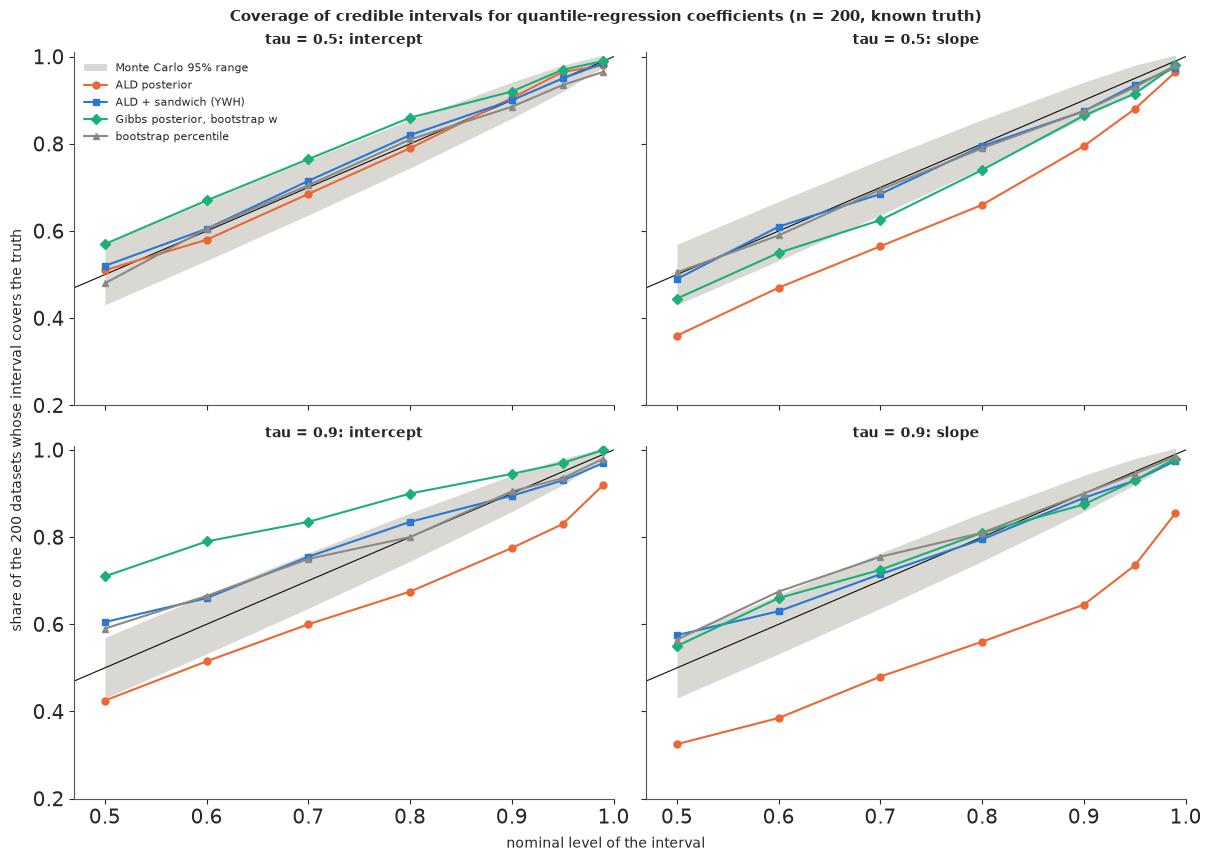

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharex=True, sharey=True)
styles = {"ALD posterior": (ORANGE, "o"), "ALD + sandwich (YWH)": (BLUE, "s"),
          "Gibbs posterior, bootstrap w": (AQUA, "D"), "bootstrap percentile": (MUTED, "^")}
band = 1.96 * np.sqrt(LEVELS * (1 - LEVELS) / R_SIM)
for row, tau in enumerate(SIM_TAUS):
    for col, par in enumerate(("intercept", "slope")):
        ax = axes[row, col]
        ax.fill_between(LEVELS, LEVELS - band, LEVELS + band, color=LIGHT, lw=0, label="Monte Carlo 95% range")
        ax.plot([0.45, 1], [0.45, 1], color=INK, lw=0.8)
        for name, (c, mk) in styles.items():
            ax.plot(LEVELS, cover[(tau, name)][:, col], marker=mk, color=c, lw=1.5, ms=5, label=name)
        ax.set_title(f"tau = {tau}: {par}", fontsize=10)
        ax.set(xlim=(0.47, 1.0), ylim=(0.2, 1.01))
fig.supxlabel("nominal level of the interval", fontsize=10)
fig.supylabel("share of the 200 datasets whose interval covers the truth", fontsize=10)
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("Coverage of credible intervals for quantile-regression coefficients (n = 200, known truth)", fontsize=11);

What the simulation shows:

* The **ALD posterior** (orange) is too narrow, and the sandwich theory predicted by how much: its sd
  was 0.95 and 0.77 of the true sampling sd (intercept, slope) at $\tau = 0.5$ and 0.65 and 0.51 at
  $\tau = 0.9$, against 1.00, 0.80, 0.66 and 0.52 from the formulas. Nominal 90% intervals covered 90% and
  80% at the median and only **78% and 65% at $\tau = 0.9$**. The damage grows towards the tails, and is
  larger for the slope, whose information comes from the high-$x$ end where the noise is largest. The
  intercept at the median is right only by coincidence - there $\sigma f(Q_\tau\mid x)$ happens to
  average out to about $\tau(1-\tau)$.
* Sample size does not help: the ratio in the formulas does not depend on $n$. More data make the ALD
  intervals narrower *and* keep them equally overconfident.
* The **sandwich** (blue) and the **bootstrap** (grey) lie on the diagonal within Monte Carlo error at every
  level (89-90% at nominal 90%).
* The **Gibbs posterior** (green) with one bootstrap-calibrated learning rate per dataset fixes the slope
  (87.5% at 90%) but at $\tau = 0.9$ *over*-covers the intercept (94.5% at 90%, 71% at 50%): a single number
  rescales the whole posterior, and here the intercept and slope needed different factors (0.66 against
  0.52). A learning rate is a scalar fix for a matrix-shaped problem; calibrate it on the quantity you
  will report, or use the sandwich.
* NUTS and the random-walk sampler agree on the first dataset (means within 0.003, sds within 0.006).

## E. Two fixes on the real data

**Fix 1, the sandwich (Yang, Wang & He 2016).** Keep the ALD draws, replace their covariance by
$\Sigma_{\rm adj}$. Cheap and automatic; the adjusted interval is a normal approximation around the
posterior mean.

**Fix 2, a generalised (Gibbs) posterior.** Drop the pretence of a likelihood. Bissiri, Holmes & Walker
(2016, *JRSS B*) showed that updating beliefs with a *loss* is coherent: the posterior is
$\pi(\beta \mid y) \propto \pi(\beta)\exp\{-w\,\sum_i\rho_\tau(y_i - x_i^\top\beta)\}$. The ALD with
$\sigma$ fixed is the special case $w = 1/\sigma$; the **learning rate** $w$ is not given by the model and
must be chosen. Syring & Martin (2019, *Biometrika*) choose it so that credible sets have their nominal
frequentist coverage, estimated by the bootstrap. We use a simpler moment-matching version: posterior
variance scales like $1/w$, so we set $w_\tau = \frac1{\hat\sigma_\tau}\times$ (geometric mean over
coefficients of posterior variance / bootstrap variance) and **refit** - it is exactly what we did in
the simulation. One number per $\tau$ can rescale the posterior but not reshape it, which is why the
simulation's intercept and slope did not come out equally well.

In [17]:
sig_hat_k = sig_ald.mean(0)
D0_hat = X.T @ X / N_TRAIN
sd_ywh = np.empty_like(sd_ald)
for k, tau in enumerate(TAUS):
    S = np.cov(post_ald[:, :, k].T)
    sd_ywh[k] = np.sqrt(np.diag(N_TRAIN * tau * (1 - tau) / sig_hat_k[k] ** 2 * S @ D0_hat @ S))
w_tau = np.exp(np.log(sd_ald ** 2 / sd_boot ** 2).mean(1)) / sig_hat_k
print(pd.DataFrame({"learning rate w": w_tau, "ALD's 1 / sigma": 1 / sig_hat_k}, index=[f"tau {t:g}" for t in TAUS]).round(2).T.to_string())
t0 = time.time()
with pm.Model(coords={"coef": COEF, "tau": TAUS}) as m_gibbs:
    beta = pm.Normal("beta", 0.0, 5.0, dims=("coef", "tau"))
    resid = y[:, None] - pt.as_tensor(X) @ beta
    pm.Potential("loss", -(w_tau * (resid * (TAUS - (resid < 0)))).sum())
    idata_gibbs = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
s_g = az.summary(idata_gibbs, var_names=["beta"], round_to=4)
print(f"Gibbs posterior: {time.time() - t0:.0f} s; divergences {int(idata_gibbs.sample_stats['diverging'].sum())}; "
      f"max r_hat {s_g['r_hat'].max():.3f}; min bulk ESS {s_g['ess_bulk'].min():.0f}")
post_gibbs = idata_gibbs.posterior["beta"].to_numpy().reshape(-1, len(COEF), K)
sd_gibbs = post_gibbs.std(0).T
summ = pd.DataFrame({"ALD": np.median(sd_ald / sd_boot, 1), "ALD + sandwich": np.median(sd_ywh / sd_boot, 1),
                     "Gibbs, calibrated w": np.median(sd_gibbs / sd_boot, 1)}, index=[f"tau {t:g}" for t in TAUS])
print("median over the 11 coefficients of (posterior sd / bootstrap sd)")
print(summ.round(2).to_string())
for name, sdm in (("sandwich", sd_ywh), ("Gibbs", sd_gibbs)):
    rr = sdm / sd_boot
    kmin, jmin = np.unravel_index(np.argmin(rr), rr.shape)
    kmax, jmax = np.unravel_index(np.argmax(rr), rr.shape)
    print(f"{name}: lowest ratio {rr.min():.2f} ({COEF[jmin]}, tau {TAUS[kmin]:g}), highest {rr.max():.2f} "
          f"({COEF[jmax]}, tau {TAUS[kmax]:g}); share of the 77 ratios within 0.8-1.25: {np.mean((rr > 0.8) & (rr < 1.25)):.0%}")

                 tau 0.05  tau 0.1  tau 0.25  tau 0.5  tau 0.75  tau 0.9  tau 0.95
learning rate w      2.52     2.71      2.93     3.42      3.53     3.95      4.26
ALD's 1 / sigma     14.95     9.63      5.99     5.10      6.57    11.97     20.25


Gibbs posterior: 4 s; divergences 0; max r_hat 1.004; min bulk ESS 1448
median over the 11 coefficients of (posterior sd / bootstrap sd)
           ALD  ALD + sandwich  Gibbs, calibrated w
tau 0.05  0.42            0.91                 1.06
tau 0.1   0.52            0.99                 0.97
tau 0.25  0.69            0.94                 1.01
tau 0.5   0.81            0.98                 0.99
tau 0.75  0.75            1.00                 1.02
tau 0.9   0.58            0.99                 1.02
tau 0.95  0.48            1.07                 1.05
sandwich: lowest ratio 0.70 (smoker, tau 0.05), highest 1.23 (college, tau 0.05); share of the 77 ratios within 0.8-1.25: 96%
Gibbs: lowest ratio 0.83 (smoker, tau 0.95), highest 1.37 (smoker, tau 0.05); share of the 77 ratios within 0.8-1.25: 99%


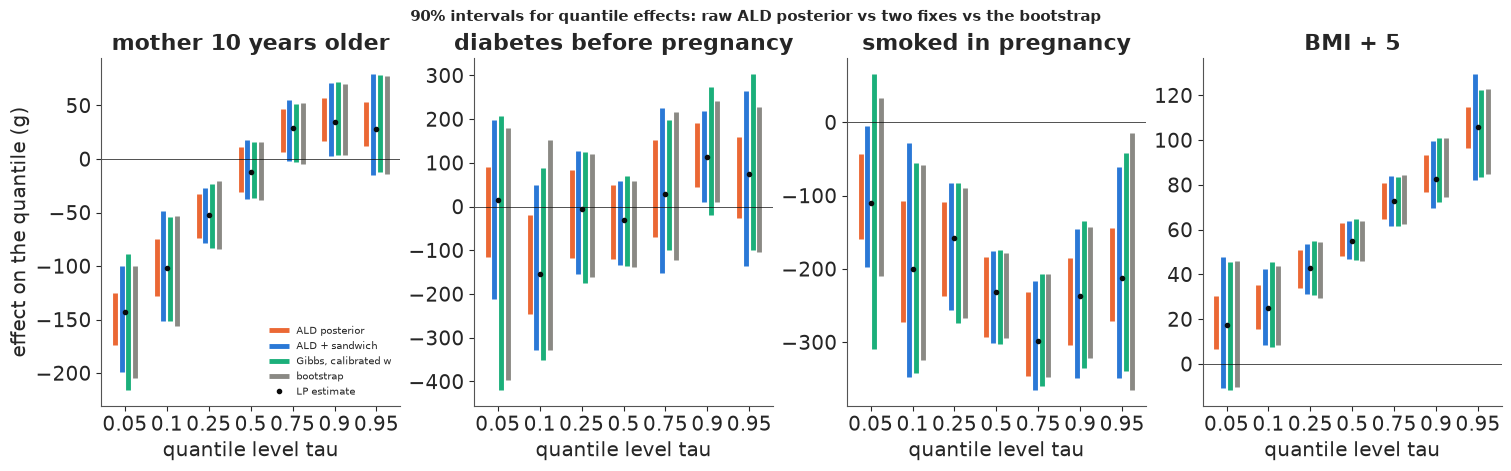

In [18]:
SHOW_E = ["age", "pre_diab", "smoker", "bmi5"]
fig, axes = plt.subplots(1, 4, figsize=(15, 4.6))
z90 = stats.norm.ppf(0.95)
xpos = np.arange(K)
for ax, cv in zip(axes, SHOW_E):
    j = COEF.index(cv)
    specs = [("ALD posterior", ORANGE, -0.24, np.quantile(post_ald[:, j, :], [0.05, 0.95], axis=0)),
             ("ALD + sandwich", BLUE, -0.08, np.array([post_ald[:, j, :].mean(0) - z90 * sd_ywh[:, j],
                                                        post_ald[:, j, :].mean(0) + z90 * sd_ywh[:, j]])),
             ("Gibbs, calibrated w", AQUA, 0.08, np.quantile(post_gibbs[:, j, :], [0.05, 0.95], axis=0)),
             ("bootstrap", MUTED, 0.24, np.quantile(boot[:, :, j], [0.05, 0.95], axis=0))]
    for name, c, off, (lo, hi) in specs:
        ax.vlines(xpos + off, lo * 1000, hi * 1000, color=c, lw=3.5, label=name)
    ax.plot(xpos, beta_hat[:, j] * 1000, "o", color=INK, ms=3, label="LP estimate")
    ax.axhline(0, color=INK, lw=0.5)
    ax.set(title=LABEL[cv], xlabel="quantile level tau", xticks=xpos, xticklabels=[f"{t:g}" for t in TAUS])
axes[0].set_ylabel("effect on the quantile (g)")
axes[0].legend(fontsize=7, loc="lower right")
fig.suptitle("90% intervals for quantile effects: raw ALD posterior vs two fixes vs the bootstrap", fontsize=11);

In [19]:
rows = []
for cv, tau in (("smoker", 0.05), ("pre_diab", 0.9), ("age", 0.95), ("bmi5", 0.05), ("age", 0.5)):
    j, k = COEF.index(cv), list(TAUS).index(tau)
    m_ = post_ald[:, j, k].mean()
    ivs = {"ALD": np.quantile(post_ald[:, j, k], [0.05, 0.95]), "sandwich": m_ + np.array([-z90, z90]) * sd_ywh[k, j],
           "Gibbs": np.quantile(post_gibbs[:, j, k], [0.05, 0.95]), "bootstrap": np.quantile(boot[:, k, j], [0.05, 0.95])}
    rows.append({"effect": f"{cv} at tau {tau:g}", "LP (g)": beta_hat[k, j] * 1000,
                 **{nm: f"{lo * 1000:5.0f} to {hi * 1000:4.0f}" for nm, (lo, hi) in ivs.items()}})
print("90% intervals (g)")
print(pd.DataFrame(rows).round(0).to_string(index=False))

90% intervals (g)
             effect  LP (g)           ALD      sandwich         Gibbs     bootstrap
 smoker at tau 0.05  -110.0  -160 to  -44  -197 to   -6  -309 to   66  -210 to   33
pre_diab at tau 0.9   114.0    45 to  192    11 to  217   -18 to  272    11 to  241
    age at tau 0.95    28.0    12 to   53   -15 to   79   -12 to   79   -14 to   78
   bmi5 at tau 0.05    17.0     7 to   30   -11 to   48   -12 to   46   -10 to   46
     age at tau 0.5   -13.0   -31 to   11   -38 to   18   -36 to   16   -38 to   16


Both fixes do their job on the real data. The median ratio of posterior sd to bootstrap sd is 0.91-1.07
for the sandwich and 0.97-1.06 for the calibrated Gibbs posterior, against 0.42-0.81 for the raw ALD. The
learning rates (2.5-4.3) are far below the ALD's implicit $1/\sigma_\tau$ (5-20): the ALD was learning
from the data 1.5-6 times too fast, most of all in the tails. Individual coefficients scatter more
(sandwich 0.70-1.23, Gibbs 0.83-1.37). The extremes are mostly the 186 smokers at the 5% and 95% levels (and
the degree coefficient at 5% for the sandwich), where the bootstrap itself is noisy - neither side of the
ratio is exact there.

Does it change conclusions? The table picks five effects. The raw ALD says that at the 5% quantile smoking
clearly lowers birth weight (-160 to -44 g), that older mothers have heavier babies at the 95% quantile (+12 to
+53 g), that BMI raises the 5% quantile (+7 to +30 g) and that pre-pregnancy diabetes raises the 90% quantile
(+45 to +192 g). With honest intervals the age and BMI effects include zero under all three methods; the
smoking interval includes zero under the bootstrap and the Gibbs posterior and only just excludes it under
the sandwich (-6 g); the diabetes interval starts at +11 g (sandwich, bootstrap) or -18 g (Gibbs). At the median,
where the ALD is least wrong, all four agree about age. The tails - where quantile regression is supposed to earn its keep - are
exactly where the raw posterior overstates what the data say.

## F. Quantile crossing: birth weight for gestational age

Doctors judge a newborn's size **for its gestational age**: "small for gestational age" usually means
below the 10th centile of birth weight among babies born at the same week. Those centile curves are a
quantile regression of birth weight on gestational age. We fit them with a cubic B-spline in the
obstetric estimate of gestation (24-42 weeks; knots at 30, 34, 37 and 39 weeks) on the training births,
first **one quantile level at a time**, at 19 levels from 5% to 95%.

Nothing forces separately fitted quantile curves to stay in order. Where data are plentiful they do;
where data are thin they can **cross** - a "10th centile" above the "15th" - which is logically
impossible for a distribution.

In [20]:
G_LO, G_HI, KNOTS = 24.0, 42.0, [30, 34, 37, 39]


def bbasis(x, k=3):
    t = np.r_[[G_LO] * (k + 1), KNOTS, [G_HI] * (k + 1)]
    nb = len(t) - k - 1
    x = np.clip(np.asarray(x, float), G_LO, G_HI - 1e-9)
    return np.column_stack([BSpline(t, np.eye(nb)[j], k)(x) for j in range(nb)])


keep_g = (tr.oegest_comb >= G_LO) & (tr.oegest_comb <= G_HI)
g_tr, yg = tr.oegest_comb[keep_g].to_numpy(float), tr.bw[keep_g].to_numpy()
keep_gt = (te.oegest_comb >= G_LO) & (te.oegest_comb <= G_HI)
g_te, yg_te = te.oegest_comb[keep_gt].to_numpy(float), te.bw[keep_gt].to_numpy()
Bm, Bm_te = bbasis(g_tr), bbasis(g_te)
ggrid = np.linspace(G_LO, G_HI, 181)
Bg = bbasis(ggrid)
print(f"training births at 24-42 weeks: {len(g_tr):,} (dropped {int((~keep_g).sum())}); "
      f"below 28 weeks: {int(np.sum(g_tr < 28))}, below 32 weeks: {int(np.sum(g_tr < 32))}")
TG19 = np.round(np.arange(0.05, 0.951, 0.05), 2)
th19 = np.array([rq_fn(Bm, yg, t) for t in TG19])
Q19 = Bg @ th19.T                                                     # grid x 19
cross_grid = (np.diff(Q19, axis=1) < 0).any(1)
Q19_tr = Bm @ th19.T
print(f"grid points (0.1 week apart) where some pair of the 19 curves is out of order: {cross_grid.sum()} "
      f"(weeks {ggrid[cross_grid].min():.1f}-{ggrid[cross_grid].max():.1f})")
print(f"training births whose 19 fitted quantiles are not in order: {(np.diff(Q19_tr, axis=1) < 0).any(1).sum()}")
edges = np.flatnonzero(np.diff(np.r_[0, cross_grid.astype(int), 0]))
print("stretches with crossing (weeks):", [f"{ggrid[a]:.1f}-{ggrid[b - 1]:.1f}" for a, b in zip(edges[::2], edges[1::2])])
odd = (g_tr < 32) & (yg > 2.5)
print(f"training births before 32 weeks: {int(np.sum(g_tr < 32))}; at 42 weeks: {int(np.sum(g_tr == 42))}. "
      "Those before 32 weeks weighing over 2.5 kg:")
print(tr[keep_g][odd][["oegest_comb", "combgest", "dbwt"]].rename(
    columns={"oegest_comb": "obstetric estimate (wk)", "combgest": "combined estimate (wk)", "dbwt": "grams"}).to_string(index=False))
Q19_sorted = np.sort(Q19, axis=1)                                     # rearrangement

training births at 24-42 weeks: 5,993 (dropped 7); below 28 weeks: 20, below 32 weeks: 59
grid points (0.1 week apart) where some pair of the 19 curves is out of order: 66 (weeks 24.0-42.0)
training births whose 19 fitted quantiles are not in order: 74
stretches with crossing (weeks): ['24.0-28.7', '29.1-30.4', '31.9-32.1', '42.0-42.0']
training births before 32 weeks: 59; at 42 weeks: 16. Those before 32 weeks weighing over 2.5 kg:
 obstetric estimate (wk)  combined estimate (wk)  grams
                      28                      38   3080
                      29                      39   3720


Two fixes:

* **Rearrangement** (Chernozhukov, Fernández-Val & Galichon 2010, *Econometrica*): at each gestational
  age, sort the fitted values. It is a one-liner, provably never moves the curves further from the truth
  (in their $L^p$ sense), and leaves curves that were already in order untouched.
* **Fit the quantile levels jointly with monotone increments.** Because B-spline basis functions are
  non-negative and sum to one, if every spline coefficient of the $(k+1)$-th curve exceeds the
  corresponding coefficient of the $k$-th, the curves cannot cross anywhere. So we write
  $\theta_{k+1} = \theta_k + \exp(\delta_k)$ (elementwise) and fit the nine levels used on clinical charts
  (3, 5, 10, 25, 50, 75, 90, 95, 97%) in one PyMC model, each with its own ALD working likelihood. The
  increments' prior (log-normal around 150 g per step) is what fills in where data are thin.

In [21]:
TGJ = np.array([0.03, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.97])
KJ, J = len(TGJ), Bm.shape[1]
th_sep = np.array([rq_fn(Bm, yg, t) for t in TGJ])
t0 = time.time()
with pm.Model(coords={"tau": TGJ, "basis": np.arange(J), "step": np.arange(KJ - 1)}) as m_joint:
    theta0 = pm.Normal("theta0", 2.5, 1.5, dims="basis")
    log_inc = pm.Normal("log_inc", np.log(0.15), 1.0, dims=("basis", "step"))
    theta = pm.Deterministic("theta", pt.concatenate(
        [theta0[:, None], theta0[:, None] + pt.cumsum(pt.exp(log_inc), axis=1)], axis=1), dims=("basis", "tau"))
    sigma_j = pm.HalfNormal("sigma", 0.5, dims="tau")
    pm.AsymmetricLaplace("y", mu=pt.as_tensor(Bm) @ theta, b=np.sqrt(TGJ * (1 - TGJ)) / sigma_j, q=TGJ,
                         observed=np.repeat(yg[:, None], KJ, axis=1))
    idata_joint = pm.sample(tune=500, draws=500, nuts={"adaptation": "low_rank"}, random_seed=RANDOM_SEED,
                            progressbar=False)
print(f"joint monotone model: {time.time() - t0:.0f} s; divergences {int(idata_joint.sample_stats['diverging'].sum())}; "
      f"max r_hat {float(az.rhat(idata_joint, var_names=['theta'])['theta'].max()):.3f}; "
      f"min ESS {float(az.ess(idata_joint, var_names=['theta'])['theta'].min()):.0f}; "
      f"tree depths { {int(a): int(c) for a, c in zip(*np.unique(idata_joint.sample_stats['depth'].to_numpy(), return_counts=True))} }")
th_joint = idata_joint.posterior["theta"].to_numpy().reshape(-1, J, KJ)
Qj = np.einsum("gj,sjk->sgk", Bg, th_joint)                           # draws x grid x 9
print("posterior draws with any crossing:", int((np.diff(Qj, axis=2) < 0).any((1, 2)).sum()))

joint monotone model: 95 s; divergences 0; max r_hat 1.007; min ESS 549; tree depths {5: 47, 6: 1952, 7: 1}
posterior draws with any crossing: 0


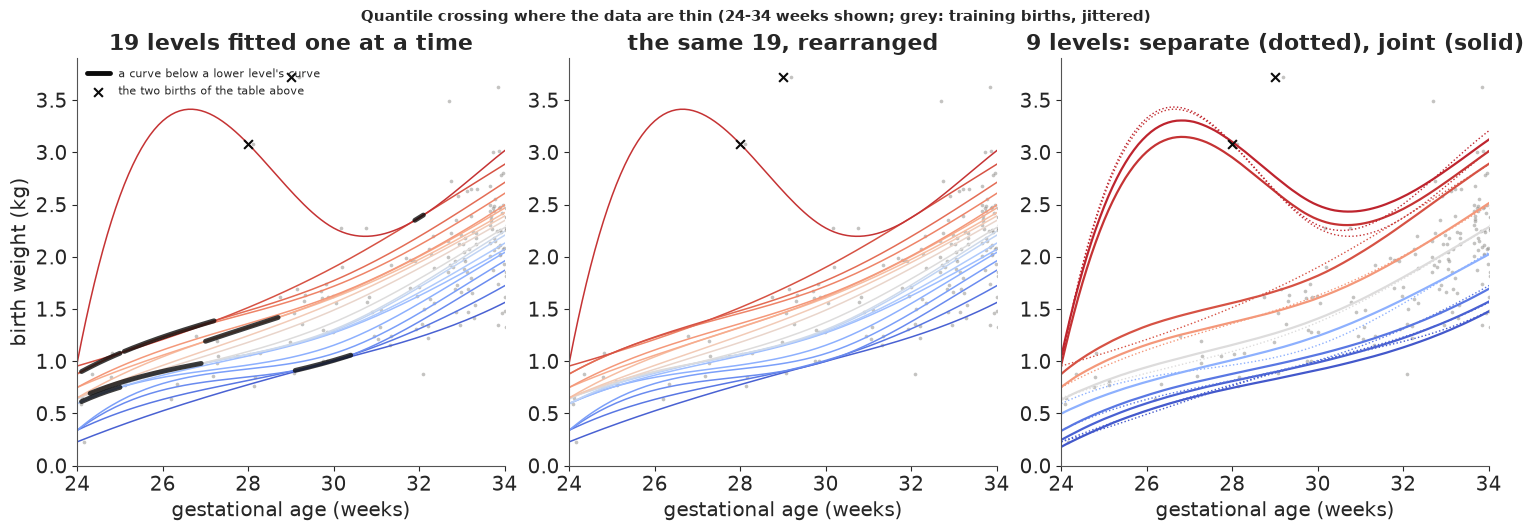

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
jit = rng.uniform(-0.35, 0.35, len(g_tr))
cmap = plt.get_cmap("coolwarm")
for ax, Q, title in ((axes[0], Q19, "19 levels fitted one at a time"),
                     (axes[1], Q19_sorted, "the same 19, rearranged")):
    ax.scatter(g_tr + jit, yg, s=7, color=MUTED, alpha=0.5, lw=0)
    ax.scatter(g_tr[odd], yg[odd], s=40, marker="x", color=INK, lw=1.5, zorder=5)
    for k, t in enumerate(TG19):
        ax.plot(ggrid, Q[:, k], color=cmap(t), lw=1.1)
    if Q is Q19:
        bad = (np.diff(Q, axis=1) < 0)
        for k in range(len(TG19) - 1):
            seg = bad[:, k]
            ax.plot(np.where(seg, ggrid, np.nan), np.where(seg, Q[:, k], np.nan), color=INK, lw=3.5, alpha=0.8)
    ax.set(xlim=(24, 34), ylim=(0, 3.9), xlabel="gestational age (weeks)", title=title)
axes[0].set_ylabel("birth weight (kg)")
axes[0].plot([], [], color=INK, lw=3.5, label="a curve below a lower level's curve")
axes[0].scatter([], [], s=40, marker="x", color=INK, label="the two births of the table above")
axes[0].legend(fontsize=8, loc="upper left")
ax = axes[2]
for k, t in enumerate(TGJ):
    ax.plot(ggrid, th_sep[k] @ Bg.T, color=cmap(t), lw=1, ls=":")
    ax.plot(ggrid, np.median(Qj[:, :, k], 0), color=cmap(t), lw=1.6)
ax.scatter(g_tr + jit, yg, s=7, color=MUTED, alpha=0.5, lw=0)
ax.scatter(g_tr[odd], yg[odd], s=40, marker="x", color=INK, lw=1.5, zorder=5)
ax.set(xlim=(24, 34), ylim=(0, 3.9), xlabel="gestational age (weeks)",
       title="9 levels: separate (dotted), joint (solid)")
fig.suptitle("Quantile crossing where the data are thin (24-34 weeks shown; grey: training births, jittered)", fontsize=11);

The separately fitted curves are out of order over 24-30 weeks (plus two short stretches at 32 and at
42 weeks), exactly where the training data run out: 20 births before 28 weeks and 16 at 42 weeks. 74 of the
5,993 training births get a set of 19 "quantiles" that is not increasing. The hump of the top curve
at 25-30 weeks is another thin-data artefact with a specific cause: two births recorded at 28 and 29 weeks by
the obstetric estimate but at 38 and 39 weeks by the combined estimate, weighing 3.1 and 3.7 kg - almost
certainly a misrecorded gestational age. A quantile curve where there are 20 births is set by one or two of
them; national reference charts remove implausible weight-for-age records before fitting.

Rearrangement puts every curve in order without touching the others (middle). The joint model (right) is in
order by construction - none of its 2,000 posterior draws crosses - and in the data-rich weeks it reproduces
the separate fits (dotted); where data are thin it departs from them, pulled towards its neighbouring levels and its
prior, and its 95% and 97% curves still follow the two suspicious births. It samples in about 100 s without
divergences ($\hat R \le 1.01$) using nutpie's low-rank mass matrix: the cumulative-sum parameterisation makes
neighbouring levels strongly correlated (in a trial with the default diagonal adaptation, seven levels and half
the draws, it needed tree depth 7-8 and about as long).

The joint model gives a full **fan chart**: each centile curve with a posterior band. Before trusting the
bands, compare their width with the bootstrap of the separately fitted curves at a few ages - the joint
model is still built from ALD working likelihoods.

In [23]:
N_BG = 100
rng_g = np.random.default_rng(RANDOM_SEED + 3)
bq = np.empty((N_BG, len(ggrid), KJ))
for bb in range(N_BG):
    i = rng_g.integers(0, len(yg), len(yg))
    bq[bb] = Bg @ np.array([rq_fn(Bm[i], yg[i], t) for t in TGJ]).T
rows = []
for wk in (28, 32, 36, 40):
    gi = np.argmin(np.abs(ggrid - wk))
    for k in (1, 4, 7):
        rows.append({"week": wk, "tau": TGJ[k], "joint median (g)": np.median(Qj[:, gi, k]) * 1000,
                     "separate LP (g)": (th_sep[k] @ Bg[gi]) * 1000, "joint posterior sd": Qj[:, gi, k].std() * 1000,
                     "bootstrap sd, separate": bq[:, gi, k].std() * 1000})
tabF = pd.DataFrame(rows)
tabF["ratio"] = tabF["joint posterior sd"] / tabF["bootstrap sd, separate"]
print(tabF.round(2).to_string(index=False))

 week  tau  joint median (g)  separate LP (g)  joint posterior sd  bootstrap sd, separate  ratio
   28 0.05            809.74           775.87               27.31                   59.90   0.46
   28 0.50           1156.53          1093.42               53.99                   78.37   0.69
   28 0.95           2950.67          3080.00              129.94                  999.56   0.13
   32 0.05           1221.49          1231.59               21.83                   69.51   0.31
   32 0.50           1803.88          1788.68               35.01                   66.90   0.52
   32 0.95           2458.00          2372.74               33.23                  192.48   0.17
   36 0.05           2056.28          2049.57               12.24                   28.30   0.43
   36 0.50           2764.92          2763.58               14.10                   20.01   0.70
   36 0.95           3537.63          3550.37               13.02                   32.09   0.41
   40 0.05           2894.60  

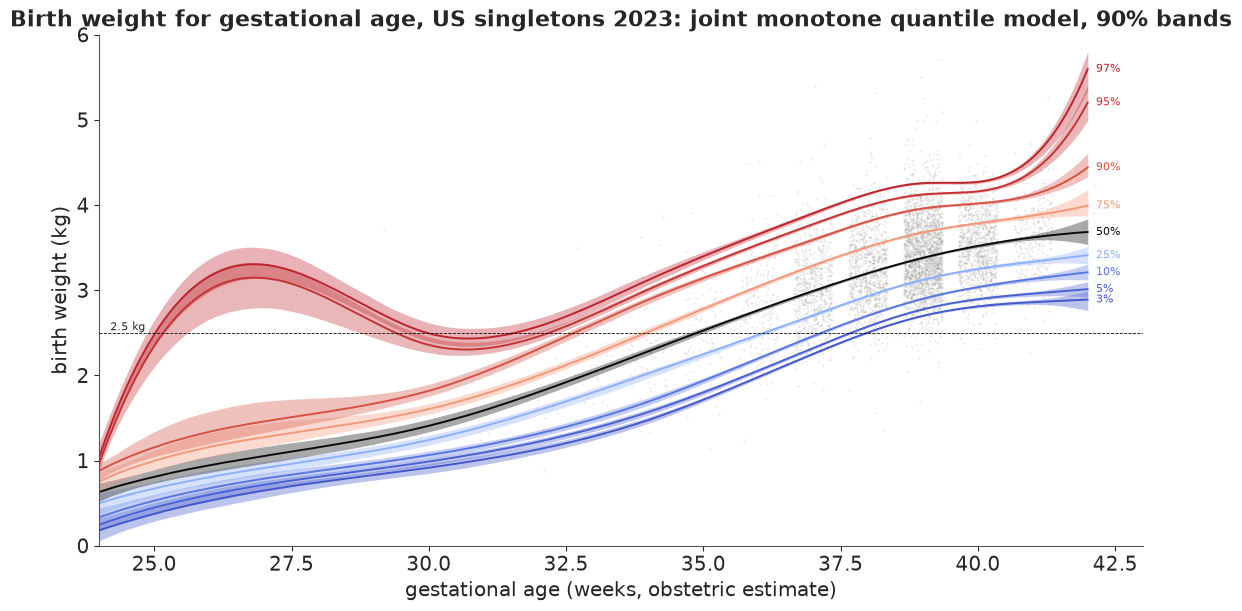

10th centile at 40 weeks: 3037 g (90% band 3022-3054); bootstrap sd of the separate fit 16 g


In [24]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(g_tr + jit, yg, s=2, color=MUTED, alpha=0.2, lw=0)
for k, t in enumerate(TGJ):
    lo, med, hi = np.quantile(Qj[:, :, k], [0.05, 0.5, 0.95], axis=0)
    col = INK if t == 0.5 else cmap(t)
    ax.fill_between(ggrid, lo, hi, color=col, alpha=0.35, lw=0)
    ax.plot(ggrid, med, color=col, lw=1.4)
    ax.text(42.15, med[-1], f"{t * 100:g}%", fontsize=8, va="center", color=col)
ax.axhline(2.5, color=INK, lw=0.6, ls="--")
ax.text(24.2, 2.53, "2.5 kg", fontsize=8)
ax.set(xlim=(24, 43), ylim=(0, 6.0), xlabel="gestational age (weeks, obstetric estimate)", ylabel="birth weight (kg)",
       title="Birth weight for gestational age, US singletons 2023: joint monotone quantile model, 90% bands")
plt.show()
p10_40 = Qj[:, np.argmin(np.abs(ggrid - 40)), 2] * 1000
print(f"10th centile at 40 weeks: {np.median(p10_40):.0f} g (90% band {np.quantile(p10_40, 0.05):.0f}-"
      f"{np.quantile(p10_40, 0.95):.0f}); bootstrap sd of the separate fit {bq[:, np.argmin(np.abs(ggrid - 40)), 2].std() * 1000:.0f} g")

The table says the joint model's bands are too narrow almost everywhere: at 40 weeks its posterior sd is
about 0.4-0.7 of the bootstrap sd of the separate fits, the familiar ALD factor. For the 95% curve in the thin
early weeks it is 0.13-0.17, because there the monotone structure and the prior also add information that the
separate fits do not have (at 28 weeks the separate 95% curve moves by about a kilogram between bootstrap
samples, depending on whether the two suspicious births are drawn). So the fan chart shows where the centiles are *well determined
relative to each other* - they are tight from 34 weeks on - but its bands are not calibrated: a 10th centile at
40 weeks of 3,037 g with a 90% band of 3,022-3,054 g (a posterior sd of about 10 g) understates the uncertainty:
the bootstrap sd of the separate fit is 16 g. The Part E fixes apply here too - a learning rate per level, calibrated by the
bootstrap - at the price of another 100-second fit. The upswing of the 95% and 97% curves at 41-42 weeks is
the spline's last basis function following 16 births.

Does fixing the order cost anything in prediction? Held-out pinball loss on the test births, summed over
the nine clinical levels:

In [25]:
Qs_te = Bm_te @ th_sep.T
Qr_te = np.sort(Qs_te, axis=1)
Qj_te = np.median(np.einsum("nj,sjk->snk", Bm_te, th_joint[::4]), 0)
loss_sep = sum(check_loss(yg_te - Qs_te[:, k], t) for k, t in enumerate(TGJ))
for name, Q in (("separate", Qs_te), ("rearranged", Qr_te), ("joint monotone (posterior median)", Qj_te)):
    li = sum(check_loss(yg_te - Q[:, k], t) for k, t in enumerate(TGJ))
    print(f"{name:35s} summed pinball loss {li.mean() * 1000:8.2f} g (vs separate {(li - loss_sep).mean() * 1000:+.2f} "
          f"+- {(li - loss_sep).std() / np.sqrt(len(li)) * 1000:.2f});  held-out births out of order: {(np.diff(Q, axis=1) < 0).any(1).sum()}")

separate                            summed pinball loss   729.14 g (vs separate +0.00 +- 0.00);  held-out births out of order: 65
rearranged                          summed pinball loss   729.14 g (vs separate -0.00 +- 0.00);  held-out births out of order: 0
joint monotone (posterior median)   summed pinball loss   728.95 g (vs separate -0.19 +- 0.07);  held-out births out of order: 0


Held out, the three sets of curves predict equally well: rearrangement changed only the 65 test births
whose quantiles were out of order, by too little to show in the average, and the joint model is better by
0.19 ± 0.07 g of summed pinball loss - significant, but tiny against 729 g. Crossing is a *coherence* problem more
than an accuracy problem: nobody wants to report a 10th centile above the 15th.

## G. Or model the whole distribution

Quantile regression is "semi-parametric": it models one quantile at a time and says nothing about the
rest. The alternative is a **generative** model for the whole conditional distribution, from which every
quantile follows - automatically in order, with one honest likelihood and one posterior. E41 did this with
P-splines and the Box-Cox t for growth charts; here we use linear predictors and a different flexible
family, the **sinh-arcsinh** (SHASH) distribution of Jones & Pewsey (2009, *Biometrika*):

$$y = \mu + \sigma\,\sinh\Bigl(\frac{\operatorname{arcsinh}(z) + \epsilon}{\delta}\Bigr),\qquad z \sim N(0, 1).$$

$\epsilon$ controls skewness ($\epsilon < 0$: a long left tail) and $\delta$ tail weight ($\delta < 1$:
heavier than normal). Its quantiles are closed form, $Q_\tau = \mu + \sigma\sinh\{(\operatorname{arcsinh}
\Phi^{-1}(\tau) + \epsilon)/\delta\}$, and its log density is

$$\log p(y) = \log\delta - \log\sigma + \tfrac12\log(1 + s^2) - \tfrac12\log(1 + u^2) - \tfrac12\log 2\pi - \tfrac12 s^2,\quad u = \tfrac{y-\mu}\sigma,\ s = \sinh(\delta\operatorname{arcsinh} u - \epsilon).$$

We let the **median** (not $\mu$), $\log\sigma$ and $\epsilon$ each depend linearly on all ten covariates,
with one $\delta$. Parameterising by the median, $\mu = m - \sigma\sinh(\epsilon/\delta)$, matters: with $\mu$,
$\log\delta$ and $\epsilon$ all free and linear, a first attempt gave 2,000 divergences in 2,000 draws
and $\hat R \approx 8$ (location and skewness trade off). With the median parameterisation and
nutpie's start-point jitter switched off, it samples cleanly. First, a check that the density integrates to one.

In [26]:
def shash_logp(yv, mu, sig, eps, dlt, xp=np):
    u = (yv - mu) / sig
    s = xp.sinh(dlt * xp.arcsinh(u) - eps)
    return xp.log(dlt) - xp.log(sig) + 0.5 * xp.log1p(s ** 2) - 0.5 * xp.log1p(u ** 2) - 0.5 * np.log(2 * np.pi) - 0.5 * s ** 2


def shash_cdf(yv, mu, sig, eps, dlt):
    return special.ndtr(np.sinh(dlt * np.arcsinh((yv - mu) / sig) - eps))


def shash_quantile(tau, mu, sig, eps, dlt):
    return mu + sig * np.sinh((np.arcsinh(special.ndtri(tau)) + eps) / dlt)


print("integral of the density:", round(integrate.quad(lambda v: np.exp(shash_logp(v, 3.3, 0.5, -0.4, 0.7)), -40, 40, limit=400)[0], 8))
zz = np.random.default_rng(1).normal(size=2_000_000)
ysim = 3.3 + 0.5 * np.sinh((np.arcsinh(zz) - 0.4) / 0.7)
print("share of 2 million simulated values below the closed-form 5%, 50%, 95% quantiles:",
      np.mean(ysim[:, None] < shash_quantile(np.array([0.05, 0.5, 0.95]), 3.3, 0.5, -0.4, 0.7), axis=0).round(4))

integral of the density: 1.0
share of 2 million simulated values below the closed-form 5%, 50%, 95% quantiles: [0.0497 0.4996 0.95  ]


Priors: $N(0, 0.25)$ kg for each median coefficient (the intercept is centred at 3.3 kg), $N(0, 0.2)$ for the
log-scale coefficients (the scale is centred at 0.5 kg) and the skewness coefficients, $N(0, 0.3)$ for
$\log\delta$. Remember that BMI and weight gain enter per 5 units and per 10 lb, and reach 7-8 units at the
extremes, so a coefficient prior multiplies up. A prior predictive check - one simulated weight for each of
4,000 prior draws, each at a randomly chosen training birth's covariates:

In [27]:
rng_pr = np.random.default_rng(RANDOM_SEED + 4)
n_pr = 4000
xm = X[rng_pr.integers(0, N_TRAIN, n_pr)]
med_pr = 3.3 + (rng_pr.normal(0, 0.25, (n_pr, len(COEF))) * xm).sum(1)
sg_pr = np.exp(np.log(0.5) + (rng_pr.normal(0, 0.2, (n_pr, len(COEF))) * xm).sum(1))
ep_pr = (rng_pr.normal(0, 0.2, (n_pr, len(COEF))) * xm).sum(1)
dl_pr = np.exp(rng_pr.normal(0, 0.3, n_pr))
y_pr = med_pr - sg_pr * np.sinh(ep_pr / dl_pr) + sg_pr * np.sinh((np.arcsinh(rng_pr.normal(size=n_pr)) + ep_pr) / dl_pr)
print("prior predictive birth weight (kg), quantiles 5/25/50/75/95%:", np.quantile(y_pr, [0.05, 0.25, 0.5, 0.75, 0.95]).round(2))
print(f"share below 0 kg: {np.mean(y_pr < 0):.1%}; above 7 kg: {np.mean(y_pr > 7):.1%};  observed: 5-95% "
      f"{np.quantile(y, 0.05):.2f}-{np.quantile(y, 0.95):.2f} kg")

prior predictive birth weight (kg), quantiles 5/25/50/75/95%: [1.46 2.74 3.33 3.91 5.14]
share below 0 kg: 1.5%; above 7 kg: 1.1%;  observed: 5-95% 2.35-4.10 kg


The prior predictive weights span about 1.5-5.1 kg (5-95%), wider than the observed 2.35-4.10 kg, with
about 1% impossible values below zero: weakly informative. (A first version with $N(0, 1)$ kg median
coefficients put 15% of prior births below zero and 14% above 7 kg.)

In [28]:
t0 = time.time()
with pm.Model(coords={"coef": COEF}) as m_shash:
    b_med = pm.Normal("b_med", 0.0, 0.25, dims="coef")
    b_sig = pm.Normal("b_sig", 0.0, 0.2, dims="coef")
    b_eps = pm.Normal("b_eps", 0.0, 0.2, dims="coef")
    log_dlt = pm.Normal("log_delta", 0.0, 0.3)
    Xt = pt.as_tensor(X)
    med = 3.3 + Xt @ b_med
    sig = pt.exp(np.log(0.5) + Xt @ b_sig)
    eps = Xt @ b_eps
    dlt = pt.exp(log_dlt)
    mu = med - sig * pt.sinh(eps / dlt)
    pm.Potential("loglik", shash_logp(y, mu, sig, eps, dlt, xp=pt).sum())
    idata_sh = pm.sample(random_seed=RANDOM_SEED, progressbar=False, compile_kwargs={"jitter_rvs": set()})
print(f"SHASH regression: {time.time() - t0:.0f} s; divergences {int(idata_sh.sample_stats['diverging'].sum())}")
for v in ("b_med", "b_sig", "b_eps", "log_delta"):
    print(f"  {v:10s} max r_hat {float(az.rhat(idata_sh, var_names=[v])[v].max()):.3f}, "
          f"min bulk ESS {float(az.ess(idata_sh, var_names=[v])[v].min()):.0f}")
sh = {v: idata_sh.posterior[v].to_numpy().reshape(-1, len(COEF)) for v in ("b_med", "b_sig", "b_eps")}
sh["dlt"] = np.exp(idata_sh.posterior["log_delta"].to_numpy().reshape(-1))
print(pd.DataFrame({"median (g)": sh["b_med"].mean(0) * 1000, "log sigma": sh["b_sig"].mean(0),
                    "epsilon (skew)": sh["b_eps"].mean(0)}, index=COEF).round(3).to_string())
print(f"delta (tail weight): {sh['dlt'].mean():.3f} (94%: {np.quantile(sh['dlt'], 0.03):.3f}-{np.quantile(sh['dlt'], 0.97):.3f})")


def shash_params(Xm, idx):
    sg = np.exp(np.log(0.5) + sh["b_sig"][idx] @ Xm.T)
    ep = sh["b_eps"][idx] @ Xm.T
    dl = sh["dlt"][idx][:, None]
    return 3.3 + sh["b_med"][idx] @ Xm.T - sg * np.sinh(ep / dl), sg, ep, dl

SHASH regression: 15 s; divergences 0
  b_med      max r_hat 1.002, min bulk ESS 3146
  b_sig      max r_hat 1.003, min bulk ESS 1911
  b_eps      max r_hat 1.004, min bulk ESS 3108
  log_delta  max r_hat 1.002, min bulk ESS 2025
           median (g)  log sigma  epsilon (skew)
intercept      -4.048     -0.506          -0.133
boy            96.449      0.034          -0.001
black        -164.226      0.026          -0.060
age           -10.083      0.102          -0.032
first         -98.077      0.016          -0.017
college        80.872     -0.073           0.006
smoker       -233.285     -0.068           0.076
bmi5           58.565      0.052           0.017
gain10         79.246     -0.002           0.042
pre_diab      -12.045      0.058           0.049
gest_hyp     -229.541      0.046          -0.031
delta (tail weight): 0.740 (94%: 0.715-0.767)


**Quantile effects implied by the generative model.** A SHASH coefficient is not a quantile effect:
a covariate moves the median, the spread and the skew at once. To compare with quantile regression we
compute, for each posterior draw, the **average conditional quantile effect**: for every training birth,
the $\tau$-quantile with the covariate switched on minus switched off (for age and BMI: plus half a unit
minus half a unit), averaged over births. For a linear quantile regression this average is exactly its
coefficient.

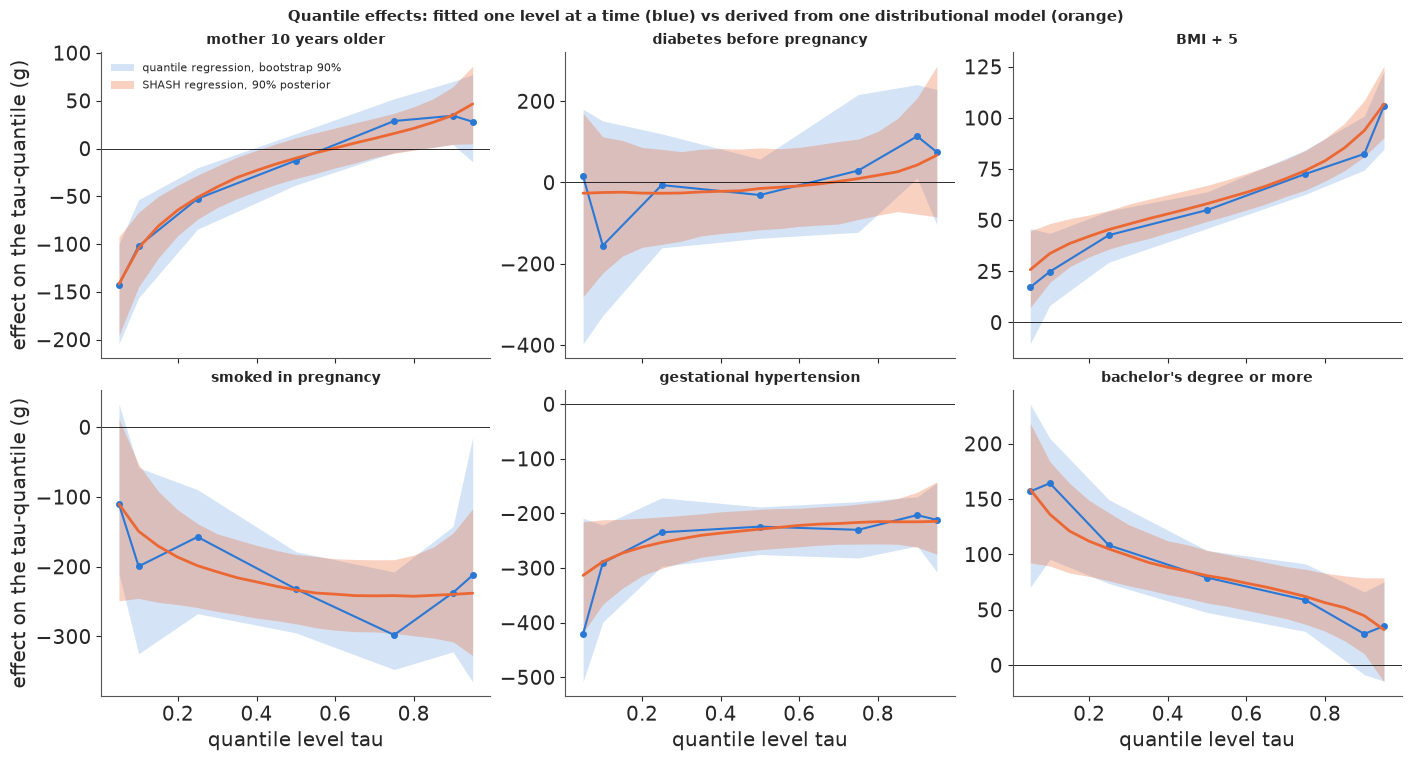

In [29]:
TG_FINE = np.round(np.arange(0.05, 0.951, 0.05), 2)
idx_d = np.random.default_rng(2).choice(len(sh["dlt"]), 400, replace=False)
qeff = {}
for cv in SHOW:
    j = COEF.index(cv)
    X1, X0 = X.copy(), X.copy()
    if cv in ("age", "bmi5"):
        X1[:, j] += 0.5
        X0[:, j] -= 0.5
    else:
        X1[:, j], X0[:, j] = 1.0, 0.0
    p1, p0 = shash_params(X1, idx_d), shash_params(X0, idx_d)
    qeff[cv] = np.stack([(shash_quantile(t, *p1) - shash_quantile(t, *p0)).mean(1) for t in TG_FINE], 1)  # draws x tau
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), sharex=True)
for ax, cv in zip(axes.ravel(), SHOW):
    j = COEF.index(cv)
    lo, hi = np.quantile(boot[:, :, j], [0.05, 0.95], axis=0) * 1000
    ax.fill_between(TAUS, lo, hi, color=BLUE, alpha=0.2, lw=0, label="quantile regression, bootstrap 90%")
    ax.plot(TAUS, beta_hat[:, j] * 1000, "o-", color=BLUE, lw=1.5, ms=4)
    qlo, qmed, qhi = np.quantile(qeff[cv], [0.05, 0.5, 0.95], axis=0) * 1000
    ax.fill_between(TG_FINE, qlo, qhi, color=ORANGE, alpha=0.3, lw=0, label="SHASH regression, 90% posterior")
    ax.plot(TG_FINE, qmed, color=ORANGE, lw=2)
    ax.axhline(0, color=INK, lw=0.6)
    ax.set_title(LABEL[cv], fontsize=10)
axes[0, 0].legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel("quantile level tau")
for ax in axes[:, 0]:
    ax.set_ylabel("effect on the tau-quantile (g)")
fig.suptitle("Quantile effects: fitted one level at a time (blue) vs derived from one distributional model (orange)", fontsize=11);

The two approaches tell the same story, and the generative one tells it with fewer wiggles. For age, BMI,
education and hypertension the SHASH-derived effects run through the middle of the quantile-regression
estimates at every level, with bands of similar width. They come out of three coefficients per covariate: age,
for example, barely moves the median (-10 g per decade) but raises $\log\sigma$ by 0.10 and makes the
left tail longer ($\epsilon$ -0.03), and together these give -140 g at the 5% quantile and +50 g at the 95%.
Where quantile regression zig-zags - smoking, diabetes - the SHASH curve is smooth, because it cannot
represent an effect that goes up, down and up again across $\tau$; whether that is a virtue (borrowing strength
across levels) or a straitjacket (the effect shape is fixed by the family) is exactly the modelling question.
The fitted $\delta = 0.74$ (tails heavier than normal) and a negative intercept for $\epsilon$ (a long left tail)
match the histogram in Part A.

### Held-out comparison

The fair test is the 12,936 births we never touched. For each model we need its predicted
$\tau$-quantiles for every held-out birth:

* **quantile regression**: the classical (= ALD posterior mode) fits, one per level;
* **SHASH**: quantiles of the posterior predictive distribution (a mixture over 100 posterior draws,
  inverted by bisection);
* **normal linear model** (OLS, constant sd): the "ordinary regression" baseline, $x^\top\hat\beta + \hat s\,\Phi^{-1}(\tau)$.

Scores: the **pinball loss** at each level (lower is better, a proper score for quantiles), the
**interval score** of the central 90% interval (Gneiting & Raftery 2007: width plus $2/\alpha$ times
any miss), and calibration - the share of held-out births below each predicted quantile, which should
equal $\tau$. For the generative models the full **PIT** (predictive CDF at the observed weight) should
look uniform.

In [30]:
idx_p = np.random.default_rng(3).choice(len(sh["dlt"]), 100, replace=False)
P_te = shash_params(Xte, idx_p)


def shash_pred_quantile(tau, params, n_iter=36):
    lo, hi = np.full(params[0].shape[1], -3.0), np.full(params[0].shape[1], 9.0)
    for _ in range(n_iter):
        mid = (lo + hi) / 2
        below = shash_cdf(mid[None], *params).mean(0) < tau
        lo, hi = np.where(below, mid, lo), np.where(below, hi, mid)
    return (lo + hi) / 2


t0 = time.time()
Qsh_te = np.stack([shash_pred_quantile(t, P_te) for t in TG_FINE], 1)
pit_sh = shash_cdf(yte[None], *P_te).mean(0)
s_ols = np.sqrt(np.sum((y - X @ ols) ** 2) / (N_TRAIN - X.shape[1]))
Qols_te = (Xte @ ols)[:, None] + s_ols * special.ndtri(TG_FINE)[None]
pit_ols = special.ndtr((yte - Xte @ ols) / s_ols)
Qqr_te = Xte @ np.array([rq_fn(X, y, t) for t in TG_FINE]).T
print(f"held-out predictions: {time.time() - t0:.0f} s; quantile-regression held-out births with crossing among 19 levels: "
      f"{(np.diff(Qqr_te, axis=1) < 0).any(1).sum()}")
rows = []
for k, t in enumerate(TG_FINE):
    if t not in (0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95):
        continue
    l_qr, l_sh, l_ols = (check_loss(yte - Q[:, k], t) for Q in (Qqr_te, Qsh_te, Qols_te))
    rows.append({"tau": t, "QR": l_qr.mean() * 1000, "SHASH": l_sh.mean() * 1000, "normal": l_ols.mean() * 1000,
                 "SHASH - QR": (l_sh - l_qr).mean() * 1000, "se": (l_sh - l_qr).std() / np.sqrt(len(yte)) * 1000,
                 "normal - QR": (l_ols - l_qr).mean() * 1000, "se ": (l_ols - l_qr).std() / np.sqrt(len(yte)) * 1000})
print("mean pinball loss on held-out births (g; lower is better) and paired differences")
print(pd.DataFrame(rows).round(2).to_string(index=False))


def interval_score(yv, lo, hi, alpha=0.1):
    return (hi - lo) + 2 / alpha * (lo - yv) * (yv < lo) + 2 / alpha * (yv - hi) * (yv > hi)


k5, k95 = list(TG_FINE).index(0.05), list(TG_FINE).index(0.95)
for name, Q in (("quantile regression", Qqr_te), ("SHASH", Qsh_te), ("normal", Qols_te)):
    lo, hi = Q[:, k5], Q[:, k95]
    print(f"{name:20s} 90% interval: coverage {np.mean((yte >= lo) & (yte <= hi)):.3f}, "
          f"mean width {np.mean(hi - lo) * 1000:.0f} g, interval score {interval_score(yte, lo, hi).mean() * 1000:.0f} g; "
          f"below 5%: {np.mean(yte < lo):.3f}, above 95%: {np.mean(yte > hi):.3f}")

held-out predictions: 14 s; quantile-regression held-out births with crossing among 19 levels: 24
mean pinball loss on held-out births (g; lower is better) and paired differences
 tau     QR  SHASH  normal  SHASH - QR   se  normal - QR  se 
0.05  65.35  65.83   66.03        0.48 0.12         0.68 0.24
0.10 100.92 101.63  102.16        0.71 0.16         1.24 0.24
0.25 163.69 163.74  165.74        0.05 0.10         2.05 0.31
0.50 193.45 193.39  194.11       -0.06 0.05         0.66 0.16
0.75 149.99 150.11  151.05        0.12 0.07         1.05 0.19
0.90  82.55  82.55   84.40        0.00 0.07         1.85 0.23
0.95  49.06  49.24   50.50        0.18 0.04         1.45 0.19
quantile regression  90% interval: coverage 0.908, mean width 1674 g, interval score 2288 g; below 5%: 0.045, above 95%: 0.047
SHASH                90% interval: coverage 0.915, mean width 1733 g, interval score 2301 g; below 5%: 0.040, above 95%: 0.045
normal               90% interval: coverage 0.923, mean width 1748 g, i

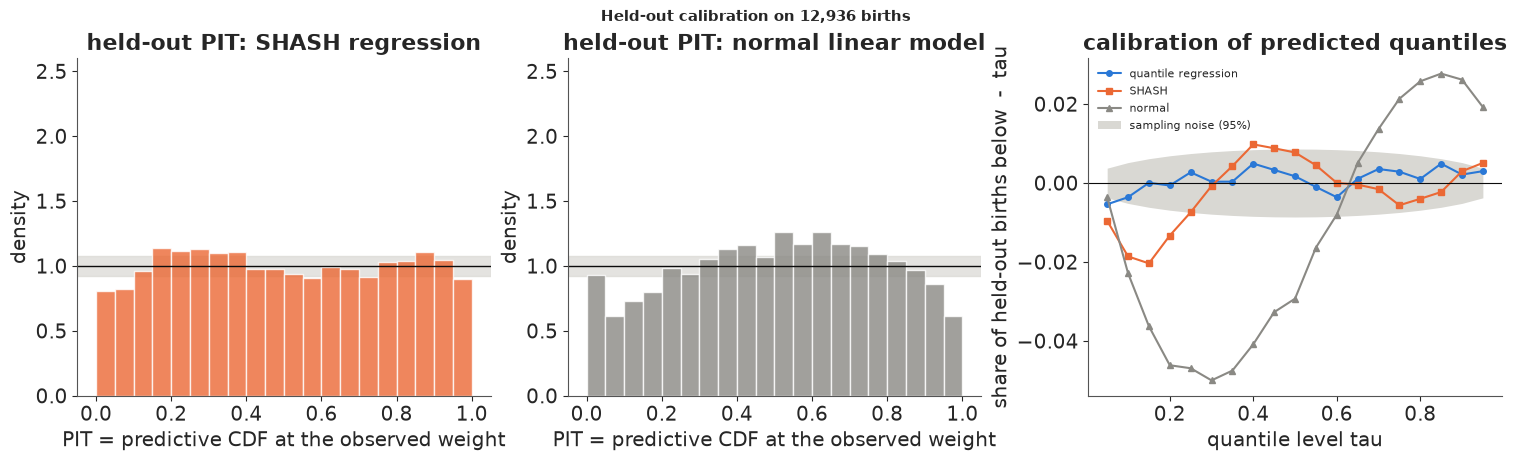

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bins = np.linspace(0, 1, 21)
for ax, pit, name, c in ((axes[0], pit_sh, "SHASH regression", ORANGE), (axes[1], pit_ols, "normal linear model", MUTED)):
    ax.hist(pit, bins=bins, weights=np.full(len(pit), 20 / len(pit)), color=c, alpha=0.8, edgecolor="white")
    ax.axhline(1, color=INK, lw=1)
    se_b = np.sqrt(0.05 * 0.95 / len(pit)) * 20
    ax.axhspan(1 - 1.96 * se_b, 1 + 1.96 * se_b, color=LIGHT, alpha=0.7, zorder=0)
    ax.set(xlabel="PIT = predictive CDF at the observed weight", ylabel="density", title=f"held-out PIT: {name}", ylim=(0, 2.6))
ax = axes[2]
for Q, name, c, mk in ((Qqr_te, "quantile regression", BLUE, "o"), (Qsh_te, "SHASH", ORANGE, "s"),
                       (Qols_te, "normal", MUTED, "^")):
    ax.plot(TG_FINE, (yte[:, None] < Q).mean(0) - TG_FINE, marker=mk, color=c, lw=1.5, ms=4, label=name)
se_c = 1.96 * np.sqrt(TG_FINE * (1 - TG_FINE) / len(yte))
ax.fill_between(TG_FINE, -se_c, se_c, color=LIGHT, lw=0, label="sampling noise (95%)")
ax.axhline(0, color=INK, lw=0.8)
ax.set(xlabel="quantile level tau", ylabel="share of held-out births below  -  tau",
       title="calibration of predicted quantiles")
ax.legend(fontsize=8)
fig.suptitle("Held-out calibration on 12,936 births", fontsize=11);

Held out, **quantile regression wins at its own game, narrowly**. It has the lowest pinball loss or ties at
every level; the SHASH model is worse at the 5%, 10% and 95% levels by 0.2-0.7 g (4-4.5 standard errors of the
paired difference) and equal in the middle. The normal linear model is worse everywhere, by 0.7-2 g (0.3-2% of
the loss). On the central 90% interval the order is the same: interval score 2,288 g (quantile regression),
2,301 g (SHASH), 2,331 g (normal). All three cover at least 90%, the normal model by being too wide at the top
(only 3.1% of births above its 95% quantile).

The calibration panels show *why*. The normal model's PIT is hump-shaped and its quantiles are off by up to 5
percentage points (at $\tau \approx 0.3$): a symmetric distribution with one spread cannot fit a long left
tail and a short right one. The SHASH PIT is much flatter but has too few births in the lowest PIT values and too
many at 0.15-0.4: its lower quantiles are placed a little too low (1-2 points fewer births below the 10-20%
quantiles than promised). Quantile regression, fitted level by level, stays within or at the edge of the
sampling band at every level (a band that ignores the estimation error of the fitted quantiles themselves) -
it has no shape to get wrong. The preterm births make the lower tail of birth weight a mixture,
not a smooth skewed shape, and one skewness parameter cannot follow it everywhere.

So which should you use? If you need one or a few quantiles and the data are plentiful, quantile regression -
with the uncertainty fixed. If you need *all* quantiles at once, coherent predictions (no crossing), a density
for decisions, or you must extrapolate where data are thin, a generative model - checked with PIT, because its
shape assumptions are exactly where it can fail.

In [32]:
print(f"total run time {time.time() - T_START:.0f} s")

total run time 244 s


## Summary

* **A quantile minimises the check loss**, and quantile regression is a linear programme. A 50-line
  Frisch-Newton interior-point solver matched scipy's HiGHS to a millionth of a gram, about 50 times faster,
  which made thousands of bootstrap fits cheap.
* **Effects differ across the distribution.** For 2023 US births, ten more years of maternal age changed the
  median by -13 g but the 5% quantile by about -140 g and the 90% quantile by about +35 g; BMI moved the 95%
  quantile six times as much as the 5%. OLS reported one number for each (-27 g, +54 g).
* **The asymmetric Laplace is a working likelihood.** Its posterior mode is exactly the classical estimate (no
  posterior draw had a lower check loss), but its spread is wrong: on the births the posterior sds were
  0.35-0.9 of the bootstrap sds, worst in the tails. With $\sigma$ fixed at 1 the width depends on the units -
  grams and kilograms differed by a factor of about 20-35.
* **Simulation with a known truth confirmed it**: nominal 90% ALD intervals covered 65-78% at $\tau = 0.9$, as
  predicted by the sandwich formula (sd ratios 0.52-0.66), and more data would not help.
* **Two fixes work.** The Yang-Wang-He sandwich adjustment of the ALD draws and a Gibbs posterior with a
  bootstrap-calibrated learning rate both gave 89-90% coverage for the slope in simulation and brought real-data
  posterior sds to within about 10% of the bootstrap (median). A scalar learning rate cannot fix the *shape* of the
  posterior (the simulation's intercept over-covered at 94.5%). On the births, honest intervals turned two of
  five "clearly non-zero" tail effects into "can't tell" under every method, and a third under two of three.
* **Separately fitted quantiles cross where data are thin** (24-30 weeks of gestation, 20 births below 28 weeks),
  and a quantile curve there is set by one or two - possibly misdated - births. Rearrangement is a free fix; a joint
  model with monotone increments across levels is non-crossing by construction and predicted held-out births as
  well, but its fan-chart bands inherit the ALD's overconfidence.
* **A generative sinh-arcsinh regression** gave every quantile at once, never crossing, with effects that agreed
  with quantile regression and varied smoothly in $\tau$. Held out, it was slightly worse in the tails (0.2-0.7 g of
  pinball loss) and its PIT showed why - the lower tail of birth weight is a mixture that one skewness parameter
  cannot follow - while the normal linear model was worse everywhere and badly calibrated.

## Try it yourself

1. **A mixture for the lower tail.** Replace the SHASH model by a two-component mixture - a main component
   and a wider, lower "early birth" component whose weight depends on the covariates (logistic link). Does the PIT
   in the lowest decile flatten, and does the held-out pinball loss at 5-10% catch up with quantile regression?
   What does the model say is the effect of age on the *share* of births in the lower component?
2. **Calibrate for coverage, not variance.** Implement Syring & Martin's algorithm for the learning rate: for a
   candidate $w$, compute the Gibbs posterior's 90% interval for the slope on each bootstrap resample of one
   simulated dataset, count how often it covers the full-data estimate, and adjust $w$ until that is 90%
   (stochastic approximation). Compare with the variance-matched $w$, and try calibrating on the intercept
   instead - how different are the two learning rates?
3. **Honest centile charts.** Remove implausible weight-for-gestational-age records (for example, births whose
   obstetric and combined gestation estimates differ by more than three weeks) and refit the 9-level joint model,
   then calibrate one learning rate per level with the bootstrap and refit. How do the 95% and 97% curves at 26-30
   weeks and the band of the 10th centile at 40 weeks change?